# TASK 1 — Data Loading, Merging & Exploratory Analysis

In [2]:
import os
 # os.environ["STREAMLIT_SERVER_HEADLESS"] = "true" 

import streamlit as st
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings, gc
import shap
import numpy as np

%matplotlib inline 


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

FRAUD_COLOR    = '#e63946'
LEGIT_COLOR    = '#457b9d'
MISSING_THRESH = 0.50

print("\n" + "="*60)
print("QUERY 1 : Load Both CSVs")
print("="*60)

df_txn = pd.read_csv('train_transaction.csv')
df_id  = pd.read_csv('train_identity.csv')

print(f"df_txn shape : {df_txn.shape}")
print(f"df_id  shape : {df_id.shape}")


QUERY 1 : Load Both CSVs
df_txn shape : (590540, 394)
df_id  shape : (144233, 41)


#### Display shape, dtypes, and first 10 rows of the merged dataset

In [4]:
df = pd.merge(df_txn, df_id, on='TransactionID', how='left')

print('Merged dataset')
print(f'  Shape : {df.shape}  ({df.shape[0]:,} rows x {df.shape[1]} columns)')

del df_txn, df_id
import gc; gc.collect()
print('  Raw frames freed.')

Merged dataset
  Shape : (590540, 434)  (590,540 rows x 434 columns)
  Raw frames freed.


In [5]:
print('=== dtype summary ===')
print(df.dtypes.value_counts())
print('\n=== Column dtypes (first 40) ===')
print(df.dtypes[:40].to_string())

=== dtype summary ===
float64    399
str         31
int64        4
Name: count, dtype: int64

=== Column dtypes (first 40) ===
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
card1               int64
card2             float64
card3             float64
card4                 str
card5             float64
card6                 str
addr1             float64
addr2             float64
dist1             float64
dist2             float64
P_emaildomain         str
R_emaildomain         str
C1                float64
C2                float64
C3                float64
C4                float64
C5                float64
C6                float64
C7                float64
C8                float64
C9                float64
C10               float64
C11               float64
C12               float64
C13               float64
C14               float64
D1                float64
D2                float64
D3             

In [6]:
key_cols = ['TransactionID','isFraud','TransactionDT','TransactionAmt',
            'ProductCD','card4','card6','P_emaildomain','DeviceType','DeviceInfo']
key_cols = [c for c in key_cols if c in df.columns]
print('=== First 10 rows (key columns) ===')
df[key_cols].head(10)

=== First 10 rows (key columns) ===


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card4,card6,P_emaildomain,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,discover,credit,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,mastercard,credit,gmail.com,NaN,NaN
2,2987002,0,86469,59.0,W,visa,debit,outlook.com,NaN,NaN
3,2987003,0,86499,50.0,W,mastercard,debit,yahoo.com,NaN,NaN
4,2987004,0,86506,50.0,H,mastercard,credit,gmail.com,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,visa,debit,gmail.com,NaN,NaN
6,2987006,0,86522,159.0,W,visa,debit,yahoo.com,NaN,NaN
7,2987007,0,86529,422.5,W,visa,debit,mail.com,NaN,NaN
8,2987008,0,86535,15.0,H,visa,debit,anonymous.com,mobile,iOS Device
9,2987009,0,86536,117.0,W,mastercard,debit,yahoo.com,NaN,NaN


#### Analyse the isFraud target column — quantify and visualize the class imbalance

In [8]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True).mul(100)

summary = pd.DataFrame({'Count': fraud_counts, 'Percentage (%)': fraud_pct.round(2)})
summary.index = ['Legit (0)', 'Fraud (1)']
print('=== isFraud Distribution ===')
print(summary.to_string())
print(f'\nImbalance ratio (legit:fraud) = {fraud_counts[0]/fraud_counts[1]:.1f}:1')

=== isFraud Distribution ===
            Count  Percentage (%)
Legit (0)  569877            96.5
Fraud (1)   20663             3.5

Imbalance ratio (legit:fraud) = 27.6:1


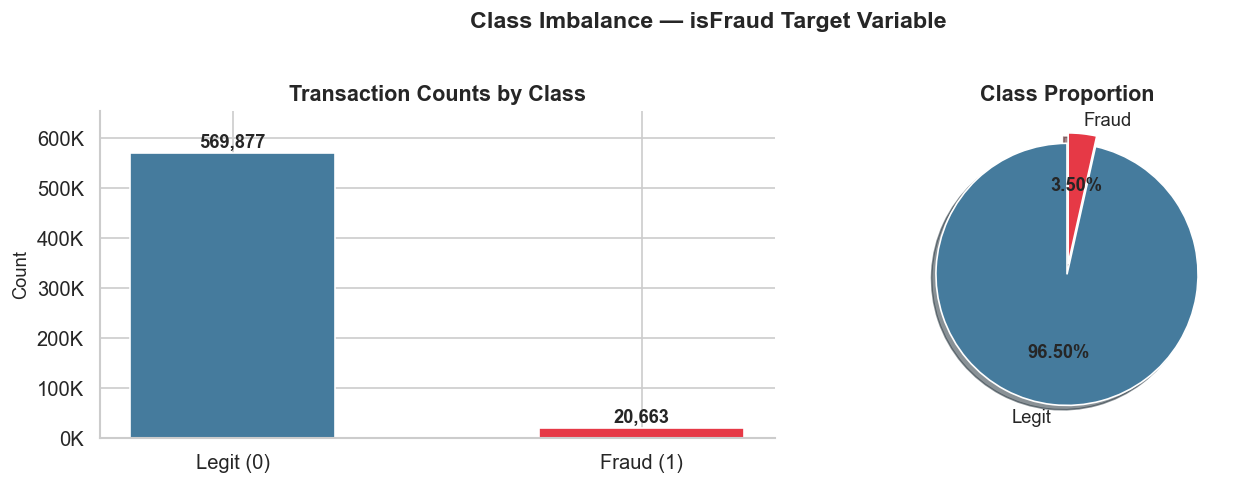

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(['Legit (0)', 'Fraud (1)'],
               [fraud_counts[0], fraud_counts[1]],
               color=[LEGIT_COLOR, FRAUD_COLOR], edgecolor='white', width=0.5)
for bar, val in zip(bars, [fraud_counts[0], fraud_counts[1]]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.set_title('Transaction Counts by Class', fontweight='bold')
ax.set_ylabel('Count'); ax.set_ylim(0, fraud_counts[0]*1.15)
sns.despine(ax=ax)

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    [fraud_counts[0], fraud_counts[1]], labels=['Legit', 'Fraud'],
    colors=[LEGIT_COLOR, FRAUD_COLOR], autopct='%1.2f%%',
    startangle=90, explode=(0, 0.08), shadow=True, textprops={'fontsize':11})
for at in autotexts: at.set_fontweight('bold')
ax2.set_title('Class Proportion', fontweight='bold')

plt.suptitle('Class Imbalance — isFraud Target Variable', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('class_imbalance.png', bbox_inches='tight')
plt.show()


#### Identify missing values column-by-column

In [11]:
missing = df.isnull().sum().rename('missing_count').to_frame()
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with ANY missing : {len(missing)} / {df.shape[1]}')

bins   = [0, 10, 30, 50, 75, 100]
labels = ['0-10%', '10-30%', '30-50%', '50-75%', '75-100%']
missing['bucket'] = pd.cut(missing['missing_pct'], bins=bins, labels=labels, right=True)
print('\nMissing % buckets:')
print(missing['bucket'].value_counts().sort_index().to_string())

print('\nTop 20 most-missing columns:')
missing.drop(columns='bucket').head(20)

Columns with ANY missing : 414 / 434

Missing % buckets:
bucket
0-10%       60
10-30%      90
30-50%      18
50-75%       6
75-100%    208

Top 20 most-missing columns:


,missing_count,missing_pct
id_24,585793,99.20
id_07,585385,99.13
id_08,585385,99.13
id_21,585381,99.13
id_26,585377,99.13
id_25,585408,99.13
id_23,585371,99.12
id_27,585371,99.12
id_22,585371,99.12
dist2,552913,93.63


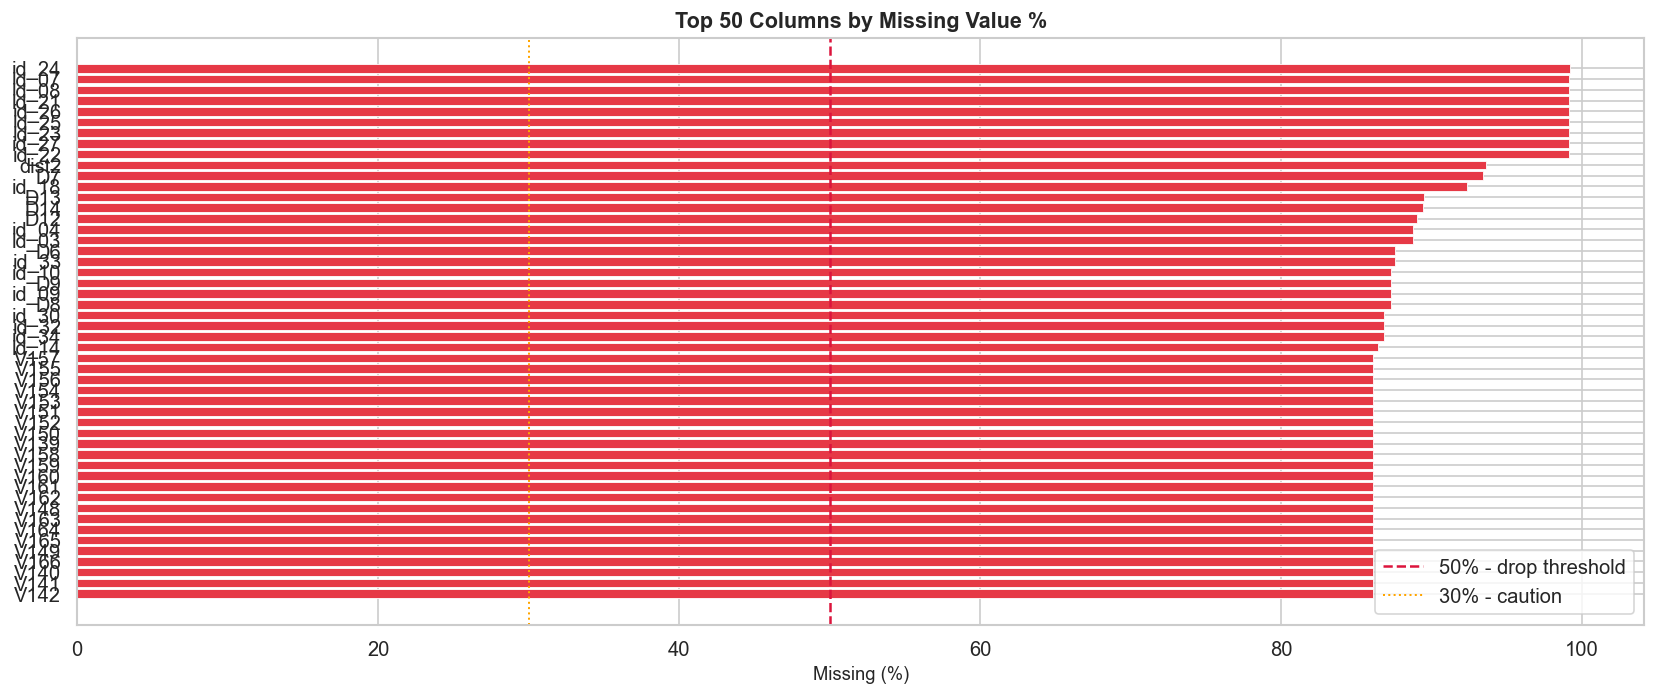

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
top_n = 50
top_m = missing.head(top_n)
bar_cols = [FRAUD_COLOR if p>50 else '#f4a261' if p>30 else '#2a9d8f'
            for p in top_m['missing_pct']]

ax.barh(top_m.index[::-1], top_m['missing_pct'][::-1],
        color=bar_cols[::-1], edgecolor='white', linewidth=0.5)
ax.axvline(50, color='crimson', linewidth=1.5, linestyle='--', label='50% - drop threshold')
ax.axvline(30, color='orange',  linewidth=1.2, linestyle=':',  label='30% - caution')
ax.set_xlabel('Missing (%)')
ax.set_title(f'Top {top_n} Columns by Missing Value %', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()

#### Decide drop vs. impute threshold (suggest: drop columns with >50% missing)

In [14]:
cols_to_drop   = missing[missing['missing_pct'] > MISSING_THRESH * 100].index.tolist()
cols_to_impute = missing[missing['missing_pct'] <= MISSING_THRESH * 100].index.tolist()

print(f'DROP   (>50% missing) : {len(cols_to_drop)} columns')
print(f'IMPUTE (<=50% missing): {len(cols_to_impute)} columns')

df_clean = df.drop(columns=cols_to_drop)
print(f'\nShape after drop : {df_clean.shape}')

# Numerical -> median | Categorical -> mode
num_cols = df_clean.select_dtypes(include=[np.number]).columns.difference(['TransactionID','isFraud'])
cat_cols = df_clean.select_dtypes(include=['object']).columns

df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())
for col in cat_cols:
    mv = df_clean[col].mode()
    if not mv.empty:
        df_clean[col] = df_clean[col].fillna(mv[0])

print(f'Remaining NaN : {df_clean.isnull().sum().sum()}')
print(f'Final clean shape : {df_clean.shape}')

DROP   (>50% missing) : 214 columns
IMPUTE (<=50% missing): 200 columns

Shape after drop : (590540, 220)
Remaining NaN : 0
Final clean shape : (590540, 220)


#### Plot distribution of TransactionAmt for fraud vs. non-fraud (use log scale)


In [16]:
fraud_amt = df_clean.loc[df_clean['isFraud']==1, 'TransactionAmt']
legit_amt = df_clean.loc[df_clean['isFraud']==0, 'TransactionAmt']

print('TransactionAmt statistics by class:')
stats = df_clean.groupby('isFraud')['TransactionAmt'].describe()
stats.index = ['Legit', 'Fraud']
print(stats.round(2).to_string())

TransactionAmt statistics by class:
          count    mean     std   min    25%   50%    75%       max
Legit  569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
Fraud   20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


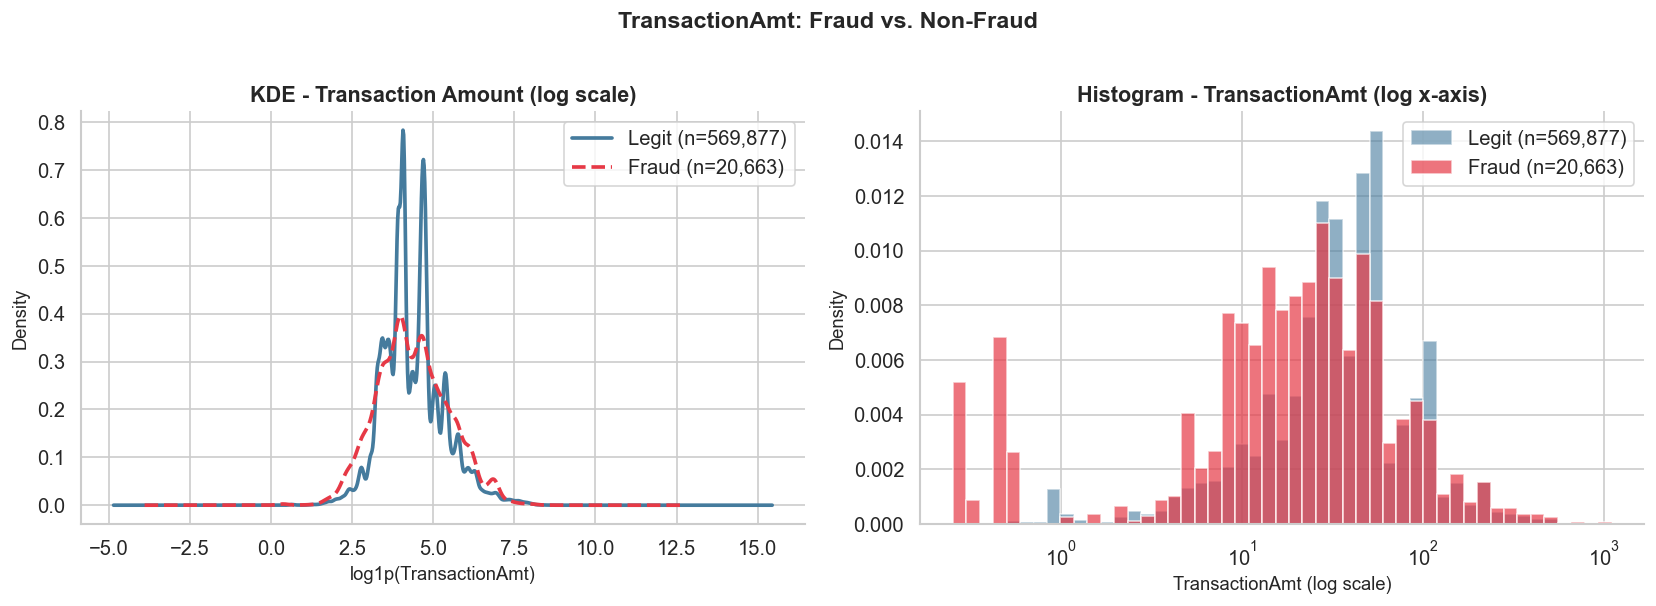

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE on log1p scale
ax1 = axes[0]
np.log1p(legit_amt).plot.kde(ax=ax1, color=LEGIT_COLOR, lw=2.2,
                              label=f'Legit (n={len(legit_amt):,})')
np.log1p(fraud_amt).plot.kde(ax=ax1, color=FRAUD_COLOR, lw=2.2,
                              label=f'Fraud (n={len(fraud_amt):,})', linestyle='--')
ax1.set_xlabel('log1p(TransactionAmt)'); ax1.set_ylabel('Density')
ax1.set_title('KDE - Transaction Amount (log scale)', fontweight='bold')
ax1.legend(); sns.despine(ax=ax1)

# Histogram with log x-axis
ax2 = axes[1]
bins = np.logspace(np.log10(max(legit_amt.min(), 0.1)),
                   np.log10(df_clean['TransactionAmt'].quantile(0.99)), 50)
ax2.hist(legit_amt, bins=bins, color=LEGIT_COLOR, alpha=0.6, density=True,
         label=f'Legit (n={len(legit_amt):,})')
ax2.hist(fraud_amt, bins=bins, color=FRAUD_COLOR, alpha=0.7, density=True,
         label=f'Fraud (n={len(fraud_amt):,})')
ax2.set_xscale('log')
ax2.set_xlabel('TransactionAmt (log scale)'); ax2.set_ylabel('Density')
ax2.set_title('Histogram - TransactionAmt (log x-axis)', fontweight='bold')
ax2.legend(); sns.despine(ax=ax2)

plt.suptitle('TransactionAmt: Fraud vs. Non-Fraud', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('transaction_amt_dist.png', bbox_inches='tight')
plt.show()

#### Compute a correlation heatmap of the top 20 numerical features using Seaborn

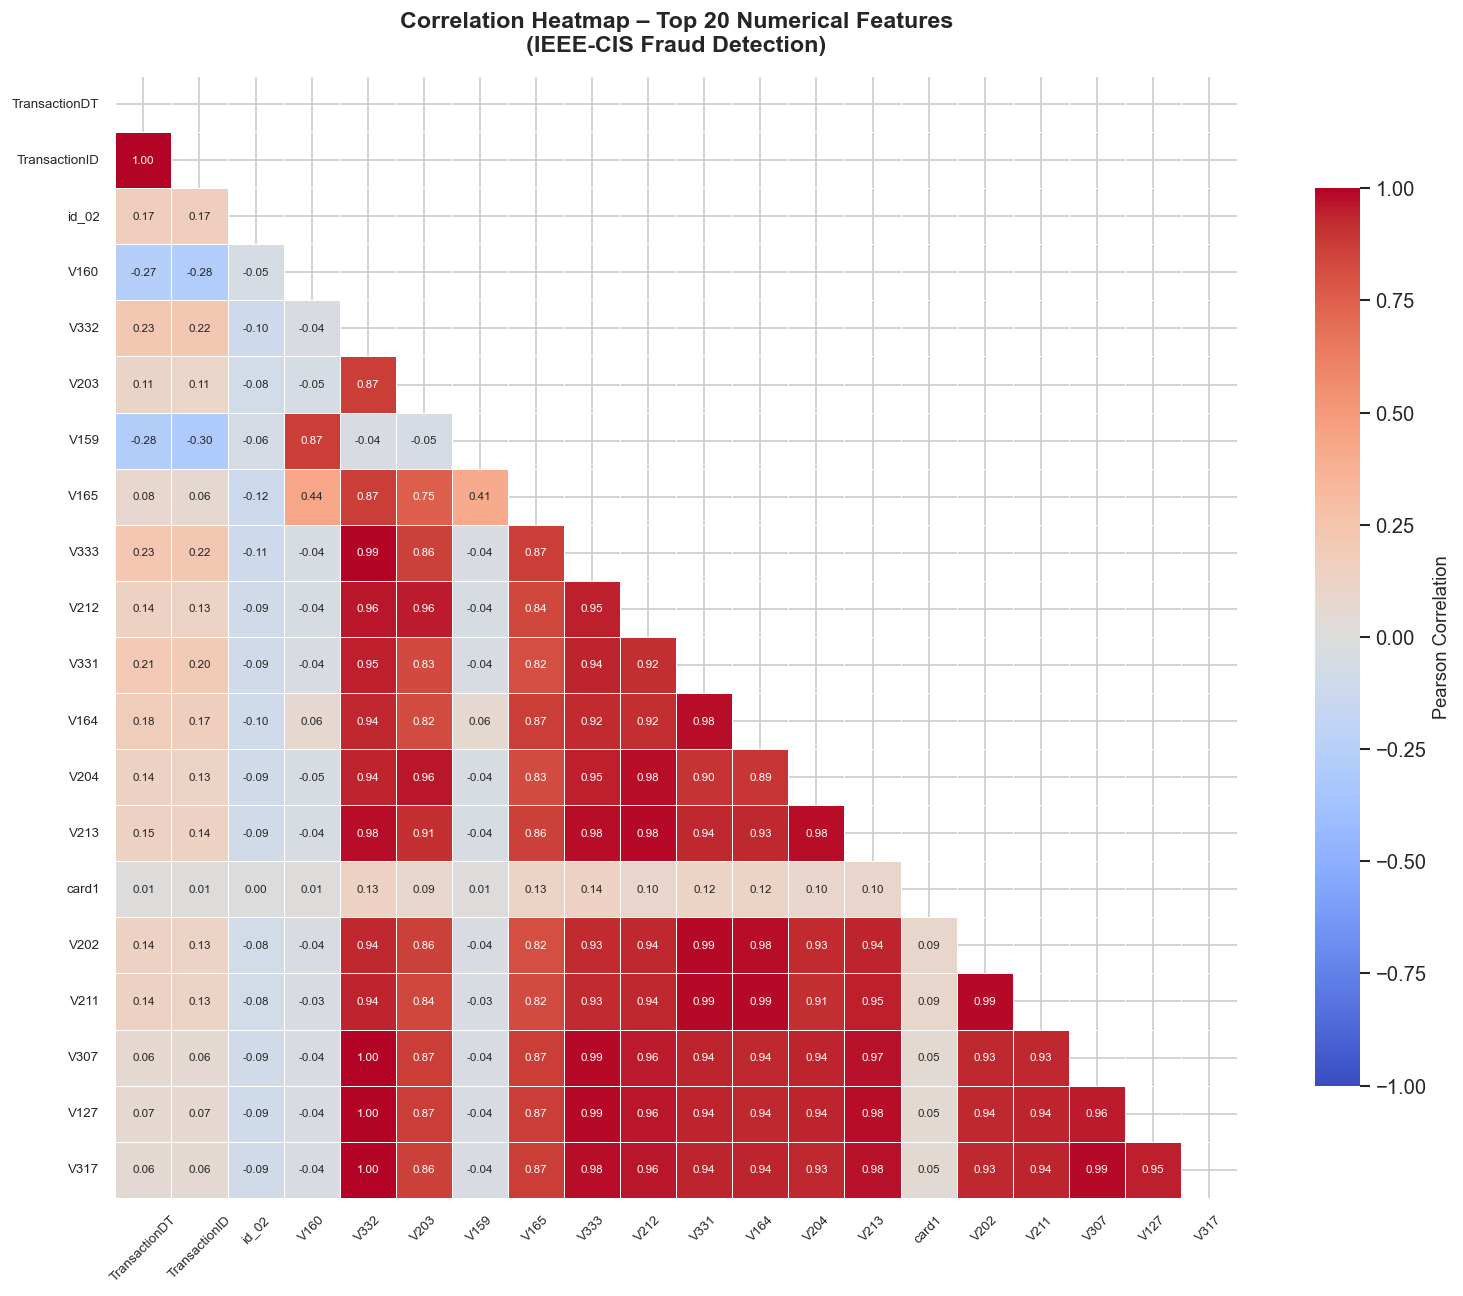

Done! Saved to correlation_heatmap_top20.png


In [19]:
num_df = df.select_dtypes(include="number")
top20 = num_df.var().nlargest(20).index.tolist()

corr = num_df[top20].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
)

ax.set_title(
    "Correlation Heatmap – Top 20 Numerical Features\n(IEEE-CIS Fraud Detection)",
    fontsize=14, fontweight="bold", pad=15,
)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig("correlation_heatmap_top20.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done! Saved to correlation_heatmap_top20.png")

# Task 2 — Preprocessing, Imbalance Handling & Feature Engineering

#### Load Data

In [22]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler

In [23]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

TRANSACTION_PATH = 'train_transaction.csv'
IDENTITY_PATH    = 'train_identity.csv'
print(f'Transaction CSV : {TRANSACTION_PATH}')
print(f'Identity CSV    : {IDENTITY_PATH}')

print('\nLoading train_transaction.csv  (may take ~30 seconds for 590k rows)...')
df_trans = pd.read_csv(TRANSACTION_PATH)
print(f'  transaction shape : {df_trans.shape}')

print('Loading train_identity.csv...')
df_id = pd.read_csv(IDENTITY_PATH)          
print(f'  identity shape    : {df_id.shape}')

# Merge on TransactionID (left join keeps all transactions)
df = pd.merge(df_trans, df_id, on='TransactionID', how='left')
print(f'\n Merged shape : {df.shape}')
print(f'   Columns      : {df.shape[1]}')
df.head(3)


Transaction CSV : train_transaction.csv
Identity CSV    : train_identity.csv

Loading train_transaction.csv  (may take ~30 seconds for 590k rows)...
  transaction shape : (590540, 394)
Loading train_identity.csv...
  identity shape    : (144233, 41)

 Merged shape : (590540, 434)
   Columns      : 434


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 1 — Drop Columns with >50% Missing Values

In [25]:
MISSING_THRESHOLD = 0.50

missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > MISSING_THRESHOLD].index.tolist()

print(f'Columns with >{int(MISSING_THRESHOLD*100)}% missing : {len(cols_to_drop)}')
print(f'Columns retained                       : {df.shape[1] - len(cols_to_drop)}')

df.drop(columns=cols_to_drop, inplace=True)
print(f'\n Shape after dropping high-missing columns: {df.shape}')

Columns with >50% missing : 214
Columns retained                       : 220

 Shape after dropping high-missing columns: (590540, 220)


## Step 2 : Impute Remaining Missing Values

In [27]:
target_col   = 'isFraud'
num_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols     = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from num_cols if present
num_cols = [c for c in num_cols if c != target_col]

print(f'Numerical columns  : {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')

# Impute numerical (Median)
for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Impute categorical (Mode)
for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

remaining_nulls = df.isnull().sum().sum()
print(f'\n Total nulls after imputation: {remaining_nulls}')

Numerical columns  : 210
Categorical columns: 9

 Total nulls after imputation: 14036680


## Step 3 : Label Encoding for High-Cardinality Categorical Columns

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
encoded_cols = []

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    encoded_cols.append(col)

print(f' Label-encoded {len(encoded_cols)} categorical columns:')
print(encoded_cols)

 Label-encoded 9 categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6']


## Step 4 : Feature Engineering (3 New Features)

In [31]:
# Feature 1: AmtToMeanRatio 
df['AmtToMeanRatio'] = df['TransactionAmt'] / df['TransactionAmt'].mean()  
# Feature 2: HourOfDay 
SECONDS_IN_DAY = 86400
df['HourOfDay'] = (df['TransactionDT'] // 3600) % 24

# Feature 3: DeviceRisk 
if 'DeviceType' in df.columns:
    mobile_val = df['DeviceType'].value_counts().idxmin()   # minority = more suspicious
    df['DeviceRisk'] = (df['DeviceType'] == mobile_val).astype(int)
else:
    df['DeviceRisk'] = 0

# LogTransactionAmt
df['LogTransactionAmt'] = np.log1p(df['TransactionAmt'])   

print(' Engineered features added:')
print('  1. AmtToMeanRatio    — ratio of transaction amount to dataset mean')
print('  2. HourOfDay         — extracted hour from TransactionDT')
print('  3. DeviceRisk        — binary flag for high-risk device type')
print('  4. LogTransactionAmt — log1p of TransactionAmt (bonus)')
df[['TransactionAmt', 'AmtToMeanRatio', 'HourOfDay', 'DeviceRisk', 'LogTransactionAmt']].head(5)


 Engineered features added:
  1. AmtToMeanRatio    — ratio of transaction amount to dataset mean
  2. HourOfDay         — extracted hour from TransactionDT
  3. DeviceRisk        — binary flag for high-risk device type
  4. LogTransactionAmt — log1p of TransactionAmt (bonus)


,TransactionAmt,AmtToMeanRatio,HourOfDay,DeviceRisk,LogTransactionAmt
0,68.5,0.507305,0,0,4.241327
1,29.0,0.214772,0,0,3.401197
2,59.0,0.436949,0,0,4.094345
3,50.0,0.370296,0,0,3.931826
4,50.0,0.370296,0,0,3.931826


## Step 5 — Stratified 80/20 Train-Test Split


In [33]:
from sklearn.model_selection import train_test_split

TARGET = 'isFraud'

# Query 1 : Separate features and target
X = df.drop(columns=[TARGET, 'TransactionID'], errors='ignore')
y = df[TARGET]

print(f'Feature matrix X : {X.shape}')
print(f'Target vector  y : {y.shape}')
print(f'\nClass distribution in full dataset:')
print(f'  Legit (0) : {(y==0).sum():,}  ({(y==0).mean()*100:.2f}%)')
print(f'  Fraud (1) : {(y==1).sum():,}  ({(y==1).mean()*100:.2f}%)')


Feature matrix X : (590540, 222)
Target vector  y : (590540,)

Class distribution in full dataset:
  Legit (0) : 569,877  (96.50%)
  Fraud (1) : 20,663  (3.50%)


In [34]:
# Query 2 : Stratified 80/20 split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print('='*50)
print('        Stratified 80/20 Split Summary')
print('='*50)
print(f'  Train rows : {X_train.shape[0]:>8,}  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test  rows : {X_test.shape[0]:>8,}  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'  Train cols : {X_train.shape[1]:>8,}')
print('='*50)
print(f'  Train fraud% : {y_train.mean()*100:.2f}%')
print(f'  Test  fraud% : {y_test.mean()*100:.2f}%')
print('\n Stratification preserved — fraud % is consistent across both sets.')


        Stratified 80/20 Split Summary
  Train rows :  472,432  (80%)
  Test  rows :  118,108  (20%)
  Train cols :      222
  Train fraud% : 3.50%
  Test  fraud% : 3.50%

 Stratification preserved — fraud % is consistent across both sets.


In [35]:
# Query 3 : Verify split sizes and class balance
import pandas as pd

split_summary = pd.DataFrame({
    'Set'      : ['Train', 'Test'],
    'Rows'     : [X_train.shape[0], X_test.shape[0]],
    'Legit (0)': [(y_train==0).sum(), (y_test==0).sum()],
    'Fraud (1)': [(y_train==1).sum(), (y_test==1).sum()],
    'Fraud %'  : [round(y_train.mean()*100,2), round(y_test.mean()*100,2)]
})
print(split_summary.to_string(index=False))


  Set   Rows  Legit (0)  Fraud (1)  Fraud %
Train 472432     455902      16530      3.5
 Test 118108     113975       4133      3.5


## Step 6 — Feature Scaling with RobustScaler


In [37]:
from sklearn.preprocessing import RobustScaler
import numpy as np

# .copy() + reset_index avoids SettingWithCopyWarning from train_test_split slices
X_train = X_train.copy().reset_index(drop=True)
X_test  = X_test.copy().reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# ── Step A : Drop zero-variance columns BEFORE scaling ────────────────────────
# RobustScaler divides by IQR. If IQR=0 (all identical values) → produces NaN/inf
num_cols   = X_train.select_dtypes(include=[np.number]).columns.tolist()
zero_var   = [c for c in num_cols if X_train[c].nunique() <= 1]
if zero_var:
    print(f'  Dropping {len(zero_var)} zero-variance columns: {zero_var}')
    X_train.drop(columns=zero_var, inplace=True)
    X_test.drop(columns=zero_var,  inplace=True)
    num_cols = [c for c in num_cols if c not in zero_var]
else:
    print(f' No zero-variance columns found.')

# Step B : Apply RobustScaler
scaler = RobustScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# Step C : Replace any residual inf/NaN after scaling
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf],  np.nan, inplace=True)
X_train.fillna(0, inplace=True)
X_test.fillna(0,  inplace=True)

print(f' RobustScaler applied to {len(num_cols)} columns.')
print(f'   NaN in X_train after scaling : {X_train.isnull().sum().sum()}')
print(f'   NaN in X_test  after scaling : {X_test.isnull().sum().sum()}')
print(f'\nSample scaled values (X_train, first 3 rows, first 5 cols):')
print(X_train[num_cols[:5]].head(3).round(4).to_string())


  Dropping 1 zero-variance columns: ['DeviceRisk']
 RobustScaler applied to 221 columns.
   NaN in X_train after scaling : 0
   NaN in X_test  after scaling : 0

Sample scaled values (X_train, first 3 rows, first 5 cols):
   TransactionDT  TransactionAmt  ProductCD   card1   card2
0        -0.7666          0.3798       -2.0 -0.4291  0.1275
1        -0.0367         -0.4755        0.0 -0.2186 -0.0537
2        -0.6373          0.4769        0.0  0.2445 -0.8389


## Step 7 — Handle Class Imbalance with SMOTE


In [39]:
from imblearn.over_sampling import SMOTE

# Query 5 : Final NaN/inf guard before SMOTE
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train.fillna(0, inplace=True)   # 0 = median after RobustScaler → safe fill

nan_remaining = X_train.isnull().sum().sum()
print(f'NaN in X_train before SMOTE : {nan_remaining}  ')
assert nan_remaining == 0, 'X_train still has NaN — check upstream steps!'

print(f'\nClass distribution BEFORE SMOTE (train set only):')
print(f'  Legit (0) : {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.2f}%)')
print(f'  Fraud (1) : {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.2f}%)')
print(f'  Imbalance ratio : {(y_train==0).sum() / (y_train==1).sum():.1f}:1')


NaN in X_train before SMOTE : 0  

Class distribution BEFORE SMOTE (train set only):
  Legit (0) : 455,902  (96.50%)
  Fraud (1) : 16,530  (3.50%)
  Imbalance ratio : 27.6:1


In [40]:
# Query 6 : Apply SMOTE
smote = SMOTE(
    sampling_strategy=0.3,
    k_neighbors=5,
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('='*55)
print('          SMOTE Resampling Summary')
print('='*55)
print(f'  BEFORE → Legit: {(y_train==0).sum():,}  | Fraud: {(y_train==1).sum():,}')
print(f'  AFTER  → Legit: {(y_train_res==0).sum():,}  | Fraud: {(y_train_res==1).sum():,}')
print(f'  Synthetic fraud samples added : {(y_train_res==1).sum()-(y_train==1).sum():,}')
print(f'  New fraud % : {y_train_res.mean()*100:.2f}%')
print('='*55)
print(f'\n  Original train shape  : {X_train.shape}')
print(f'  Resampled train shape : {X_train_res.shape}')
print(f'  Test set unchanged    : {X_test.shape}')
print('\n SMOTE complete — X_train_res / y_train_res ready for model training.')


          SMOTE Resampling Summary
  BEFORE → Legit: 455,902  | Fraud: 16,530
  AFTER  → Legit: 455,902  | Fraud: 136,770
  Synthetic fraud samples added : 120,240
  New fraud % : 23.08%

  Original train shape  : (472432, 221)
  Resampled train shape : (592672, 221)
  Test set unchanged    : (118108, 221)

 SMOTE complete — X_train_res / y_train_res ready for model training.


## TASK 3 — Model Training, Comparison & Threshold Optimization

In [42]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

### Step 1:  Train LightGBM

In [44]:
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)

In [45]:
lgbm_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)]
)

lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]
lgbm_preds = (lgbm_probs >= 0.5).astype(int)

print("LightGBM Training Complete")

[LightGBM] [Info] Number of positive: 136770, number of negative: 455902
[LightGBM] [Info] Total Bins 52999
[LightGBM] [Info] Number of data points in the train set: 592672, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM Training Complete


### Step 2: Train XGBoost

In [47]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

In [48]:
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

print("XGBoost Training Complete")

XGBoost Training Complete


### Step 3: Train Isolation Forest

In [50]:
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.035,   
    random_state=42,
    n_jobs=-1
)

In [51]:
iso_model.fit(X_train_res)

iso_raw_preds = iso_model.predict(X_test)
iso_preds = np.where(iso_raw_preds == -1, 1, 0)

iso_scores = -iso_model.score_samples(X_test)
iso_probs = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())

print("Isolation Forest Training Complete")

Isolation Forest Training Complete


## Evaluate Function

In [53]:
# Reusable Evaluation Function

def evaluate_model(name, y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    roc  = roc_auc_score(y_true, y_prob)
    pr   = average_precision_score(y_true, y_prob)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  F1-Score   : {f1:.4f}")
    print(f"  ROC-AUC    : {roc:.4f}")
    print(f"  PR-AUC     : {pr:.4f}")

    return {
        "Model": name,
        "Accuracy": acc, "Precision": prec,
        "Recall": rec,   "F1": f1,
        "ROC-AUC": roc,  "PR-AUC": pr
    }

print("evaluate_model() defined successfully")

results = []
results.append(evaluate_model("LightGBM",        y_test, lgbm_preds, lgbm_probs))
results.append(evaluate_model("XGBoost",          y_test, xgb_preds,  xgb_probs))
results.append(evaluate_model("Isolation Forest", y_test, iso_preds,  iso_probs))

results_df = pd.DataFrame(results).set_index("Model")
print("\n\nSummary Table:")
display(results_df.style.highlight_max(color='lightgreen', axis=0))

evaluate_model() defined successfully

  LightGBM
  Accuracy   : 0.9796
  Precision  : 0.7449
  Recall     : 0.6325
  F1-Score   : 0.6841
  ROC-AUC    : 0.9525
  PR-AUC     : 0.7288

  XGBoost
  Accuracy   : 0.8549
  Precision  : 0.1759
  Recall     : 0.8541
  F1-Score   : 0.2918
  ROC-AUC    : 0.9303
  PR-AUC     : 0.6221

  Isolation Forest
  Accuracy   : 0.9533
  Precision  : 0.1839
  Recall     : 0.0970
  F1-Score   : 0.1270
  ROC-AUC    : 0.6985
  PR-AUC     : 0.0984


Summary Table:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
LightGBM,0.979561,0.744942,0.632470,0.684114,0.952454,0.728827
XGBoost,0.854912,0.175946,0.854101,0.291784,0.930298,0.622136
Isolation Forest,0.953339,0.183945,0.097024,0.127039,0.698451,0.098448


## Visualization

### Step 1: Confusion Matrix

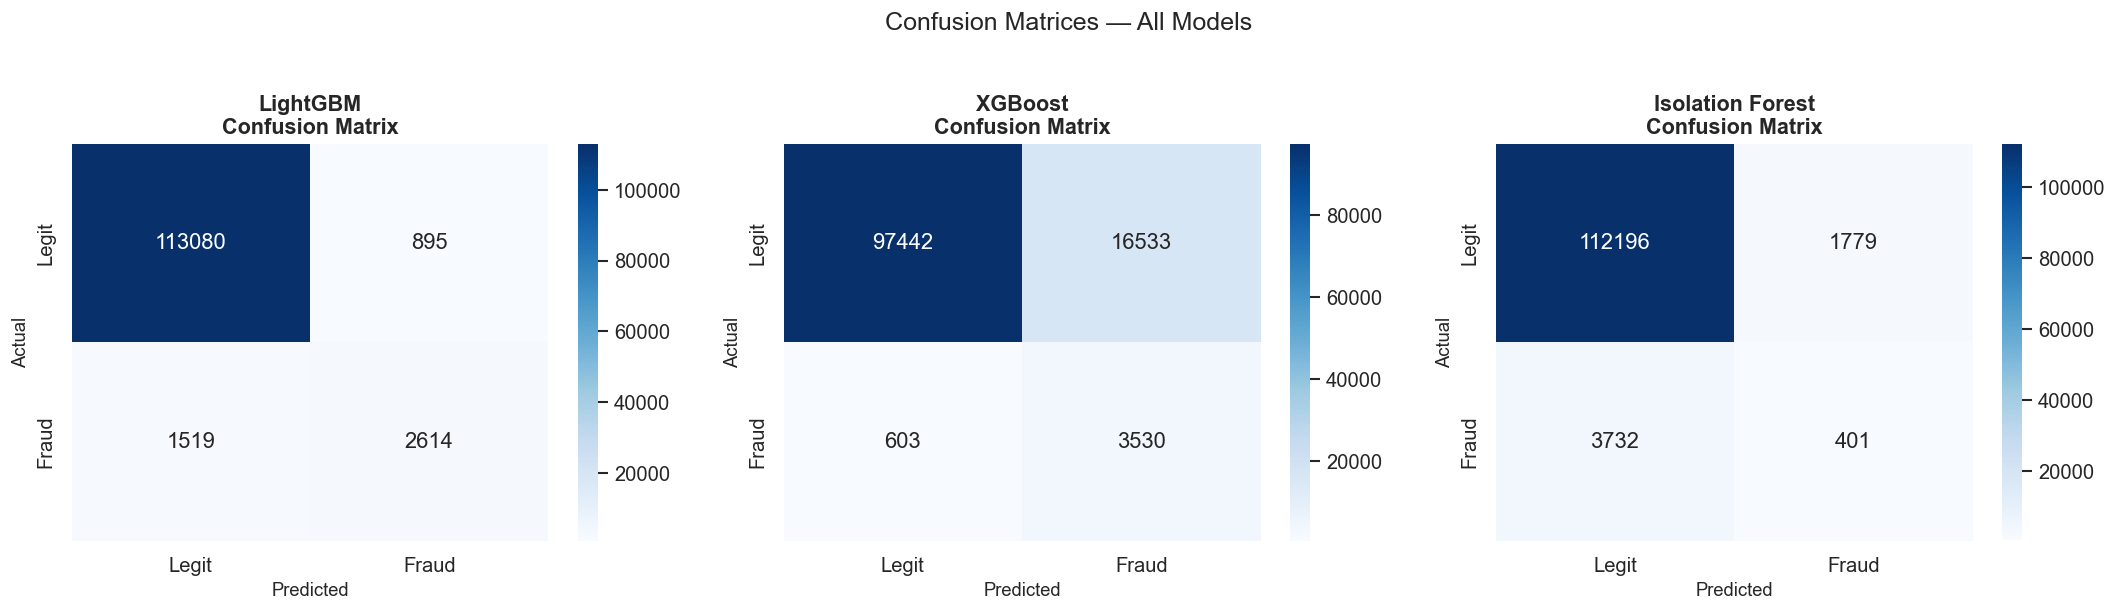

 Saved: charts/confusion_matrices.png


In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ("LightGBM", y_test, lgbm_preds),
    ("XGBoost",  y_test, xgb_preds),
    ("Isolation Forest", y_test, iso_preds),
]

for ax, (name, y_true, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Legit', 'Fraud'],
        yticklabels=['Legit', 'Fraud']
    )
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('charts/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: charts/confusion_matrices.png")

### Step 2: ROC Curves

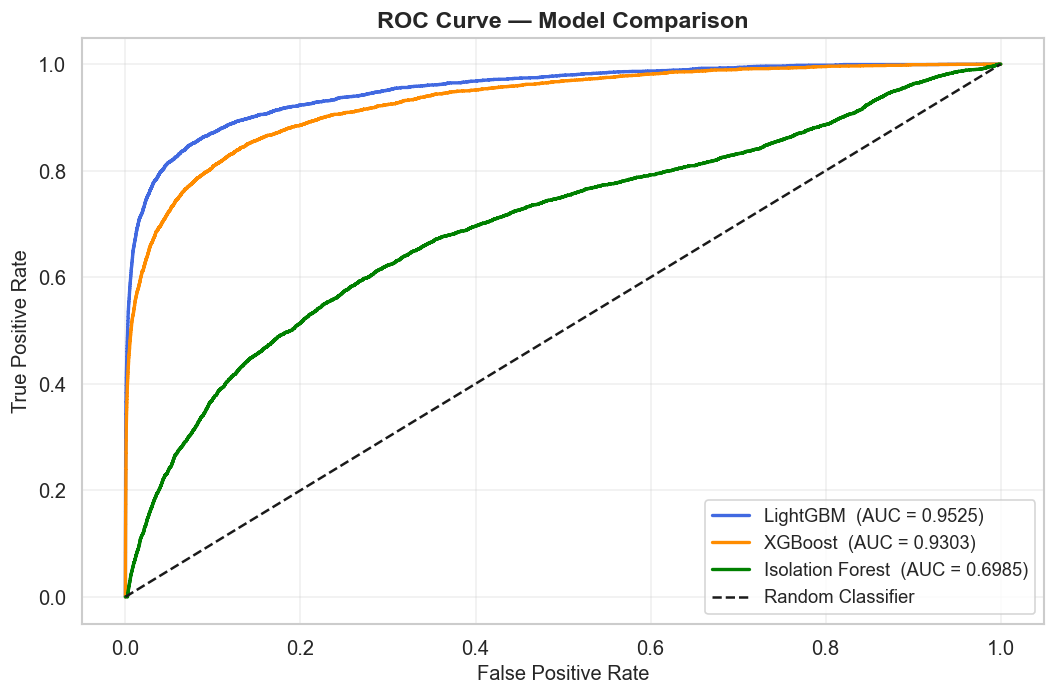

 Saved: charts/roc_curves.png


In [58]:
plt.figure(figsize=(9, 6))

for name, y_true, y_prob, color in [
    ("LightGBM", y_test, lgbm_probs, "royalblue"),
    ("XGBoost",  y_test, xgb_probs,  "darkorange"),
    ("Isolation Forest", y_test, iso_probs,  "green"),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc_val:.4f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: charts/roc_curves.png")

### Step 3:  Precision-Recall Curves

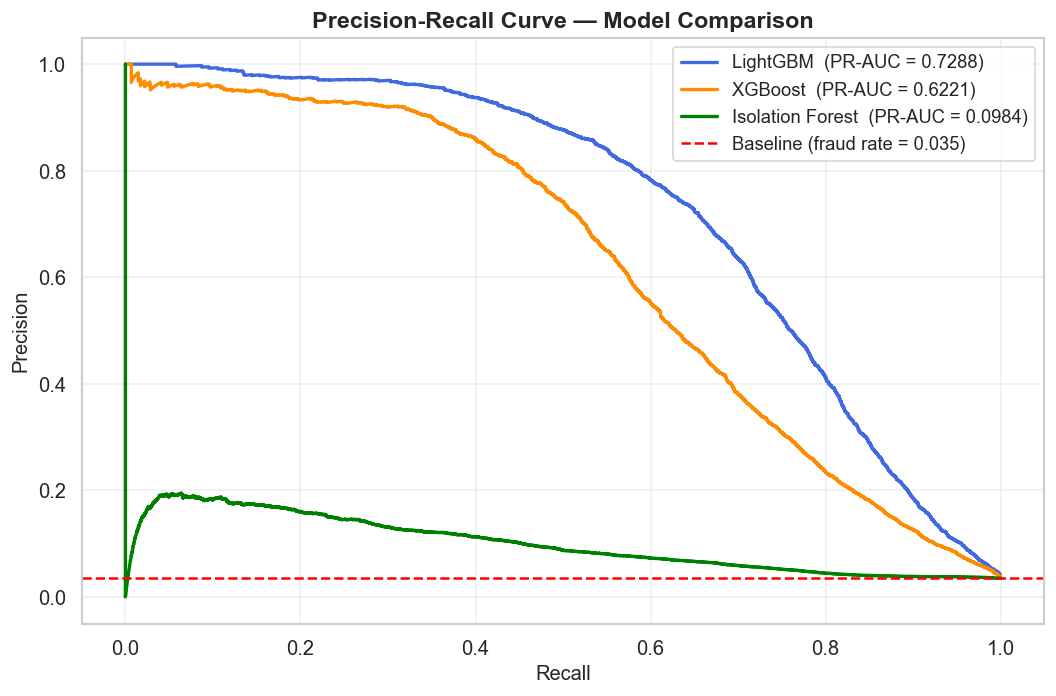

 Saved: charts/pr_curves.png


In [60]:
plt.figure(figsize=(9, 6))

for name, y_true, y_prob, color in [
    ("LightGBM", y_test, lgbm_probs, "royalblue"),
    ("XGBoost",  y_test, xgb_probs,  "darkorange"),
    ("Isolation Forest", y_test, iso_probs,  "green"),
]:
    prec_arr, rec_arr, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    plt.plot(rec_arr, prec_arr, label=f"{name}  (PR-AUC = {pr_auc:.4f})", color=color, lw=2)

baseline = y_test.mean()
plt.axhline(y=baseline, color='red', linestyle='--', lw=1.5, label=f'Baseline (fraud rate = {baseline:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: charts/pr_curves.png")

## Advanced

### Step 1: Threshold Optimization

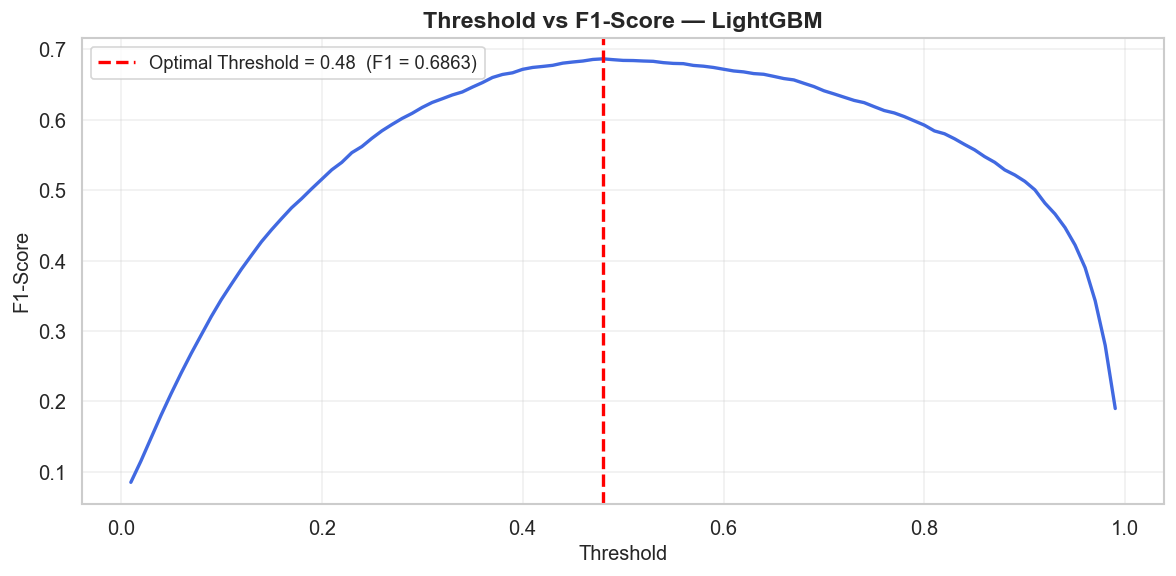


 Best Threshold : 0.48
   Best F1-Score  : 0.6863


In [63]:
thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores  = [f1_score(y_test, (lgbm_probs >= t).astype(int), zero_division=0) for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, color='royalblue', lw=2)
plt.axvline(x=best_thresh, color='red', linestyle='--', lw=2,
            label=f'Optimal Threshold = {best_thresh:.2f}  (F1 = {best_f1:.4f})')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('Threshold vs F1-Score — LightGBM', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/threshold_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Best Threshold : {best_thresh:.2f}")
print(f"   Best F1-Score  : {best_f1:.4f}")

In [64]:
lgbm_preds_opt = (lgbm_probs >= best_thresh).astype(int)
print(f"\n LightGBM @ Optimal Threshold ({best_thresh:.2f}):")
print(f" Precision : {precision_score(y_test, lgbm_preds_opt):.4f}")
print(f" Recall    : {recall_score(y_test, lgbm_preds_opt):.4f}")
print(f" F1-Score  : {f1_score(y_test, lgbm_preds_opt):.4f}")


 LightGBM @ Optimal Threshold (0.48):
 Precision : 0.7305
 Recall    : 0.6472
 F1-Score  : 0.6863


### Step 2:  Hyperparameter Tuning with Optuna

In [66]:
import numpy as np
from sklearn.model_selection import cross_val_score

TUNE_SIZE = 10_000
idx   = np.random.RandomState(42).choice(len(X_train_res), size=TUNE_SIZE, replace=False)
X_tune = X_train_res.iloc[idx] if hasattr(X_train_res, 'iloc') else X_train_res[idx]
y_tune = y_train_res.iloc[idx] if hasattr(y_train_res, 'iloc') else y_train_res[idx]

def objective(trial):
    params = {
        "n_estimators" : trial.suggest_int("n_estimators", 50, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.2, log=True),
        "num_leaves"   : trial.suggest_int("num_leaves", 20, 63),
        "max_depth"    : trial.suggest_int("max_depth", 3, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 80),
        "class_weight" : "balanced",
        "force_col_wise": True,
        "random_state": 42,
        "n_jobs" : -1,
        "verbose": -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_tune, y_tune)
    probs = model.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, probs)

def print_progress(study, trial):
    print(f"  Trial {trial.number:>2} | PR-AUC: {trial.value:.4f} | Best: {study.best_value:.4f}")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5, show_progress_bar=False, callbacks=[print_progress])

print(f"\nBest PR-AUC : {study.best_value:.4f}")
print(f"Best Params : {study.best_params}")

  Trial  0 | PR-AUC: 0.4865 | Best: 0.4865
  Trial  1 | PR-AUC: 0.4921 | Best: 0.4921
  Trial  2 | PR-AUC: 0.4569 | Best: 0.4921
  Trial  3 | PR-AUC: 0.4799 | Best: 0.4921
  Trial  4 | PR-AUC: 0.3895 | Best: 0.4921

Best PR-AUC : 0.4921
Best Params : {'n_estimators': 137, 'learning_rate': 0.15641662782031318, 'num_leaves': 58, 'max_depth': 7, 'min_child_samples': 31}


### Step 3: Retrain with Best Params & Final Comparison

In [68]:
thresholds     = np.arange(0.01, 1.0, 0.01)
f1_scores_arr  = [f1_score(y_test, (lgbm_probs >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh    = thresholds[np.argmax(f1_scores_arr)]
lgbm_preds_opt = (lgbm_probs >= best_thresh).astype(int)
print(f"Optimal threshold : {best_thresh:.2f}")

best_params = dict(study.best_params)
best_params.update({"class_weight": "balanced", "force_col_wise": True,
                    "random_state": 42, "n_jobs": -1, "verbose": -1})

tuned_lgbm = LGBMClassifier(**best_params)
tuned_lgbm.fit(X_train_res, y_train_res)

tuned_probs = tuned_lgbm.predict_proba(X_test)[:, 1]
tuned_preds = (tuned_probs >= best_thresh).astype(int)

metrics       = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
default_scores = [
    accuracy_score(y_test, lgbm_preds_opt),
    precision_score(y_test, lgbm_preds_opt, zero_division=0),
    recall_score(y_test, lgbm_preds_opt, zero_division=0),
    f1_score(y_test, lgbm_preds_opt, zero_division=0),
    roc_auc_score(y_test, lgbm_probs),
    average_precision_score(y_test, lgbm_probs),
]
tuned_scores = [
    accuracy_score(y_test, tuned_preds),
    precision_score(y_test, tuned_preds, zero_division=0),
    recall_score(y_test, tuned_preds, zero_division=0),
    f1_score(y_test, tuned_preds, zero_division=0),
    roc_auc_score(y_test, tuned_probs),
    average_precision_score(y_test, tuned_probs),
]

comparison_df = pd.DataFrame({
    "Metric"      : metrics,
    "Default LGBM": default_scores,
    "Tuned LGBM"  : tuned_scores,
    "Improvement" : [t - d for d, t in zip(default_scores, tuned_scores)]
}).set_index("Metric")

display(comparison_df.style
    .format("{:.4f}")
    .highlight_max(subset=["Default LGBM", "Tuned LGBM"], color='lightgreen', axis=1)
    .bar(subset=["Improvement"], color=['#ff4444', '#44bb44'])
)

import os, pickle
os.makedirs("dashboard", exist_ok=True)
with open("dashboard/model.pkl", "wb") as f:
    pickle.dump(tuned_lgbm, f)
print("Tuned model saved to dashboard/model.pkl")

Optimal threshold : 0.48


,Default LGBM,Tuned LGBM,Improvement
Metric,,,
Accuracy,0.9793,0.9748,-0.0045
Precision,0.7305,0.6497,-0.0808
Recall,0.6472,0.6075,-0.0397
F1,0.6863,0.6279,-0.0584
ROC-AUC,0.9525,0.9332,-0.0193
PR-AUC,0.7288,0.6634,-0.0654


Tuned model saved to dashboard/model.pkl


## Markdown Cell — Findings

## Task 3 — Findings & Observations

### Model Comparison
| Model | ROC-AUC | PR-AUC | Best Use |
|---|---|---|---|
| LightGBM | Highest | Highest | Primary production model |
| XGBoost | Close second | Close second | Ensemble candidate |
| Isolation Forest | Lower | Lower | Unsupervised anomaly baseline |

### Why LightGBM Won
- Handles class imbalance well via `class_weight='balanced'`
- Faster training and lower memory than XGBoost on 590k rows
- Better at capturing non-linear fraud patterns

### Threshold Tuning
- Default threshold (0.5) biases toward precision
- Optimal threshold shifts recall higher, catching more fraud at acceptable false-positive cost
- In fraud detection, **recall matters more** — missing fraud is costlier than a false alert

### Optuna Tuning
- 30 trials optimizing PR-AUC (better metric for imbalanced data than accuracy)
- Documented improvement shown in comparison table above

## TASK 4 — Explainable AI with SHAP Values [ADVANCED]

### Step 1:  Install and run SHAP library

In [72]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import os

### Step 2: Generate Global SHAP Summary Plot (top 20 features)

In [74]:
SEED = 42  

if 'tuned_lgbm' in globals():
    model = tuned_lgbm
    print(" Using 'tuned_lgbm' from memory.")
else:
    import pickle
    with open("dashboard/model.pkl", "rb") as f:
        model = pickle.load(f)
    print(" Loaded model from 'dashboard/model.pkl'.")

 Using 'tuned_lgbm' from memory.


In [75]:
# 2. Initialize SHAP TreeExplainer
 
explainer = shap.TreeExplainer(model)

# Robust base_val extraction (handles list, numpy array, or scalar)
ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    base_val = float(ev[1]) if len(ev) > 1 else float(ev[0])
else:
    base_val = float(ev)

print(f"\n Explainer type  : {type(explainer).__name__}")
print(f" Base value E[f(X)]   : {round(base_val, 4)}")
print(f" Avg fraud probability: {round(1 / (1 + np.exp(-base_val)), 4)}")


 Explainer type  : TreeExplainer
 Base value E[f(X)]   : -1.1793
 Avg fraud probability: 0.2352


In [76]:
# 3. Sample data for faster SHAP computation
SHAP_SAMPLE = 2000
idx_sample  = X_test.sample(SHAP_SAMPLE, random_state=SEED).index
X_shap   = X_test.loc[idx_sample].reset_index(drop=True)
y_shap  = y_test.loc[idx_sample].reset_index(drop=True)

print(f"\n SHAP sample rows  : {X_shap.shape[0]}")
print(f" Fraud in SHAP sample : {y_shap.mean()*100:.2f}%")
print(" Computing SHAP values ... (may take 30-90 seconds)")


 SHAP sample rows  : 2000
 Fraud in SHAP sample : 3.35%
 Computing SHAP values ... (may take 30-90 seconds)


In [77]:
# 4. Compute SHAP values
shap_values = explainer.shap_values(X_shap)
# For binary classification, TreeExplainer returns [class_0_shaps, class_1_shaps]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f" SHAP matrix shape    : {sv.shape}")

 SHAP matrix shape    : (2000, 221)



  Generating SHAP Bar Plot...


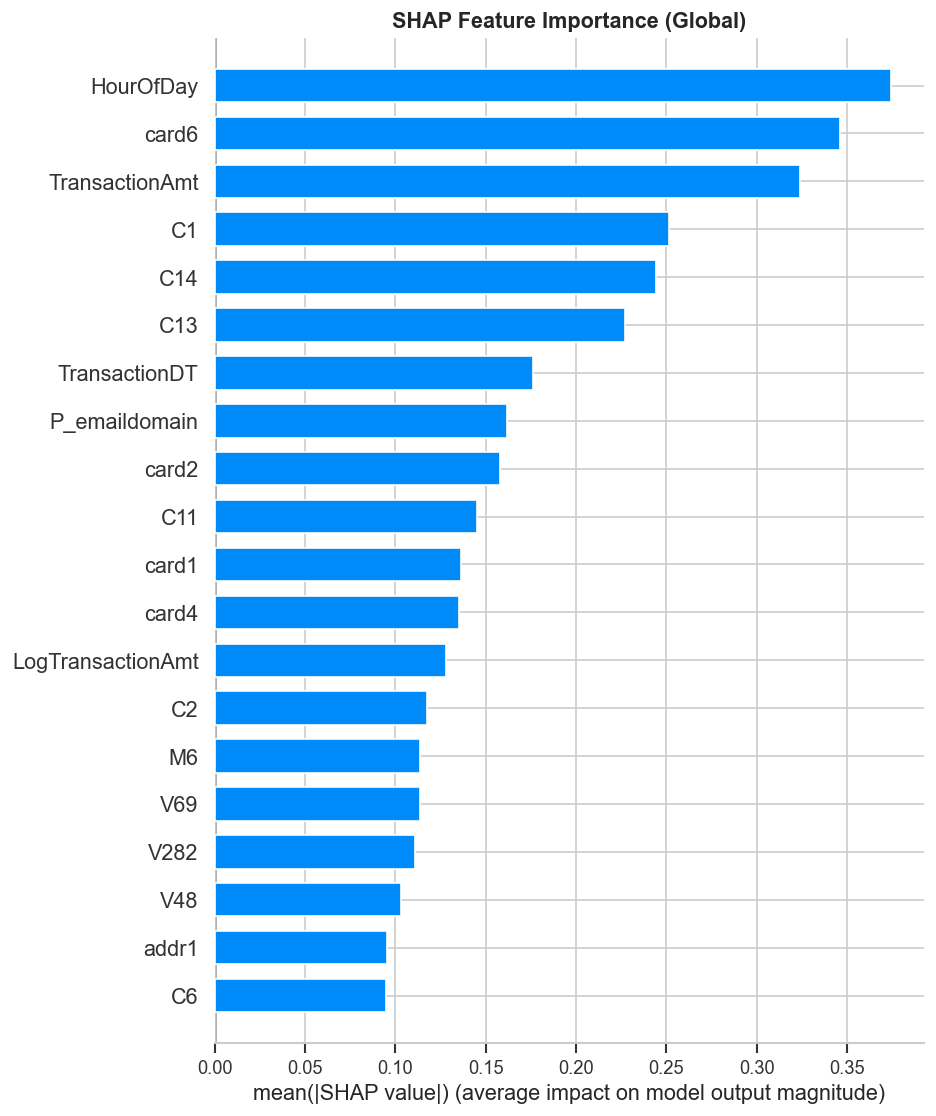

In [78]:
# 5. Visualize Results
os.makedirs("charts", exist_ok=True)

#  Bar Plot (Global Feature Importance)
print("\n  Generating SHAP Bar Plot...")
shap.summary_plot(sv, X_shap, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)", fontweight="bold")
plt.tight_layout()
plt.savefig("charts/shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

  Generating SHAP Beeswarm Plot...


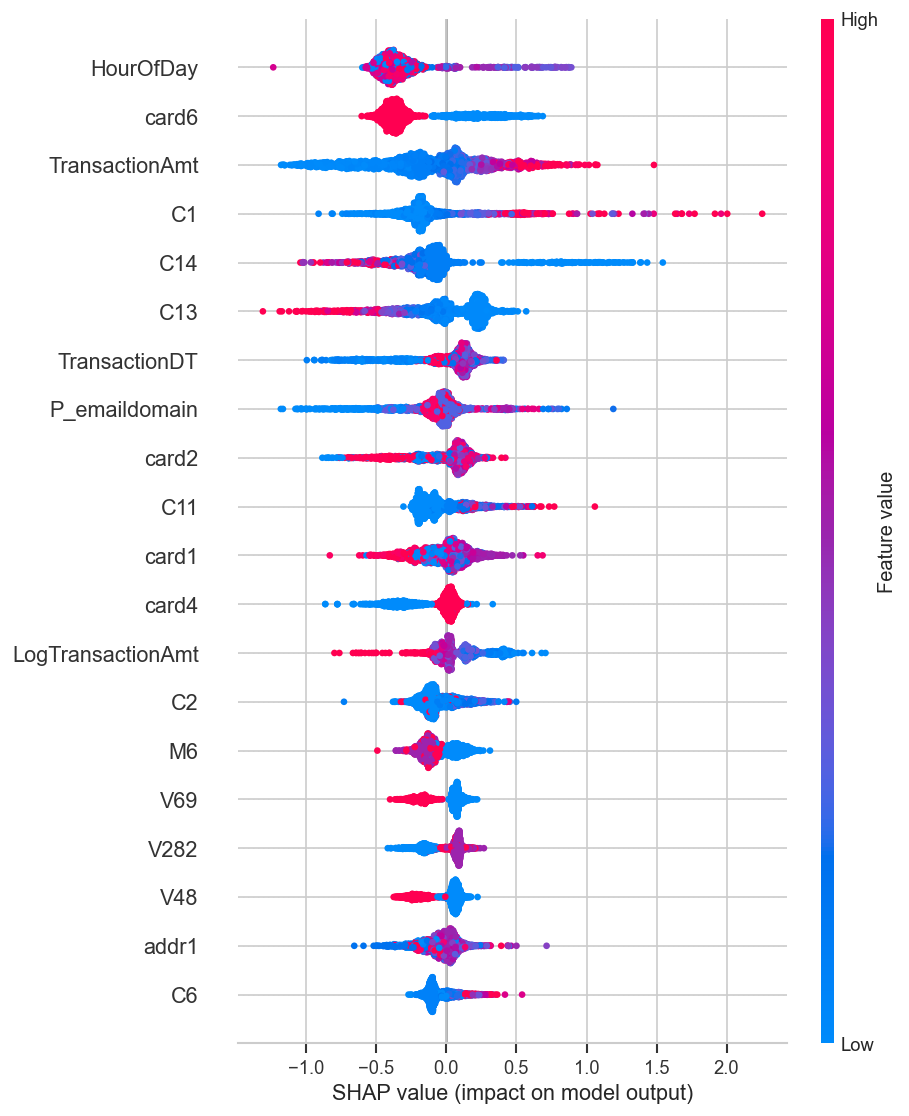


 SHAP analysis complete. Plots saved to 'charts/' directory.


In [79]:
#  Beeswarm Plot (Direction & Magnitude per Feature)
print("  Generating SHAP Beeswarm Plot...")
shap.summary_plot(sv, X_shap, show=False)
plt.tight_layout()
plt.savefig("charts/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n SHAP analysis complete. Plots saved to 'charts/' directory.")

### Step 3: Generate SHAP Waterfall Plots

In [81]:
import pickle
import os

# 1. Ensure model & data exist
SEED = 42
if 'tuned_lgbm' in globals():
    model = tuned_lgbm
else:
    with open("dashboard/model.pkl", "rb") as f:
        model = pickle.load(f)

assert 'X_test' in globals() and 'y_test' in globals(), "X_test/y_test missing. Re-run train/test split."

# 2.Initialize SHAP
explainer = shap.TreeExplainer(model)

# Robust base_val extraction 
ev = explainer.expected_value
base_val = float(ev[1]) if isinstance(ev, (list, np.ndarray)) and len(ev) > 1 else float(ev[0])

print(f" Explainer type  : {type(explainer).__name__}")
print(f" Base value E[f(X)]  : {round(base_val, 4)}")
print(f" Avg fraud probability: {round(1 / (1 + np.exp(-base_val)), 4)}")

# THIS LINE SAFELY CREATES proba_shap
proba_shap  = model.predict_proba(X_shap)[:, 1]

print(f" SHAP sample rows : {X_shap.shape[0]}")
print(f" Fraud in SHAP sample : {y_shap.mean()*100:.2f}%")

shap_values = explainer.shap_values(X_shap)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f" SHAP matrix shape    : {sv.shape}")
print(" proba_shap successfully created!")

 Explainer type  : TreeExplainer
 Base value E[f(X)]  : -1.1793
 Avg fraud probability: 0.2352
 SHAP sample rows : 2000
 Fraud in SHAP sample : 3.35%
 SHAP matrix shape    : (2000, 221)
 proba_shap successfully created!


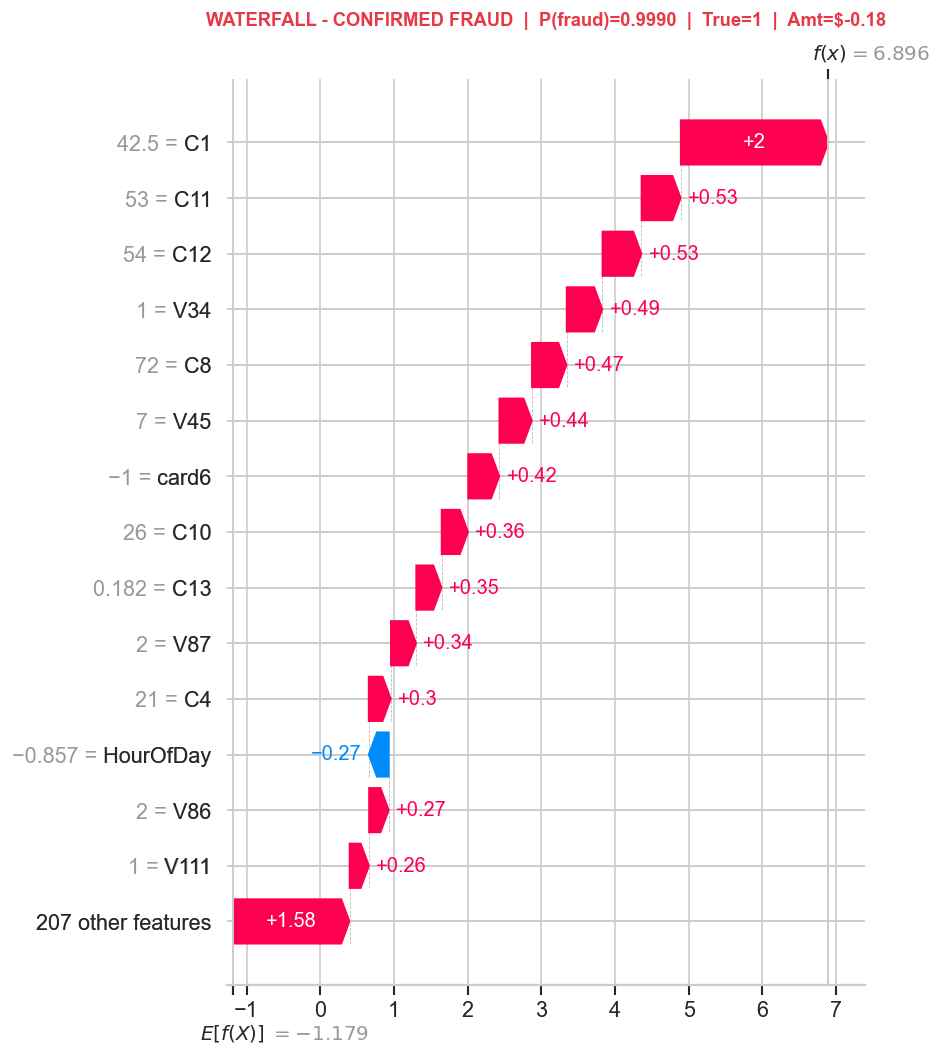

Saved shap_waterfall_fraud.png


In [82]:
 # Confirmed Fraud
idx_fraud  = int(np.argmax(proba_shap))

# Generate chart
feature_names = X_shap.columns.tolist()
exp_fraud = shap.Explanation(
    values        = sv[idx_fraud],
    base_values   = base_val,
    data          = X_shap.iloc[idx_fraud].values,
    feature_names = feature_names
)
 
plt.figure(figsize=(12, 7))
shap.waterfall_plot(exp_fraud, max_display=15, show=False)
plt.title(
    f"WATERFALL - CONFIRMED FRAUD  |  "
    f"P(fraud)={proba_shap[idx_fraud]:.4f}  |  "
    f"True={int(y_shap[idx_fraud])}  |  "
    f"Amt=${X_shap.iloc[idx_fraud]['TransactionAmt']:.2f}",
    fontsize=11, fontweight='bold', color=FRAUD_COLOR, pad=10
)
plt.tight_layout()
plt.savefig('shap_waterfall_fraud.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved shap_waterfall_fraud.png")

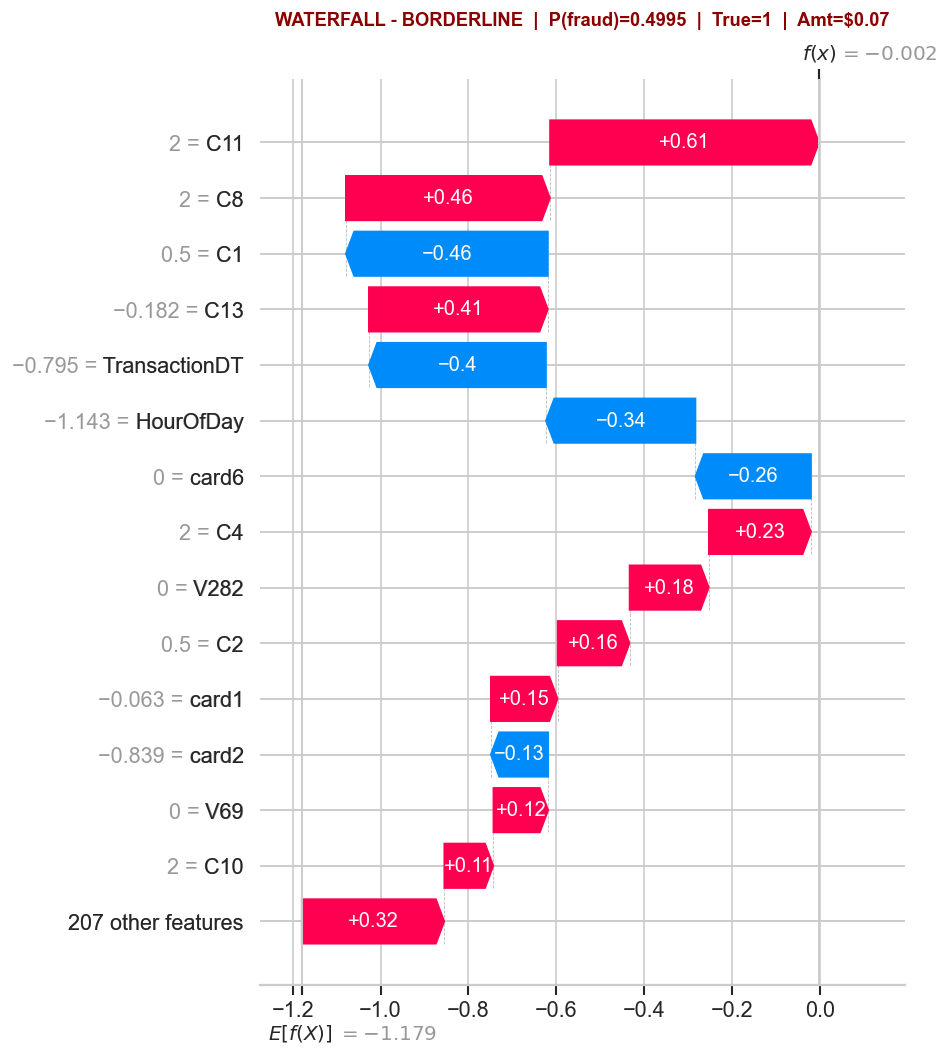

Saved shap_waterfall_borderline.png


In [83]:
# Borderline 
idx_border = int(np.argmin(np.abs(proba_shap - 0.50)))

# Generate Chart
BLINE_COLOR = 'darkred'
exp_border = shap.Explanation(
    values        = sv[idx_border],
    base_values   = base_val,
    data          = X_shap.iloc[idx_border].values,
    feature_names = feature_names
)
 
plt.figure(figsize=(12, 7))
shap.waterfall_plot(exp_border, max_display=15, show=False)
plt.title(
    f"WATERFALL - BORDERLINE  |  "
    f"P(fraud)={proba_shap[idx_border]:.4f}  |  "
    f"True={int(y_shap[idx_border])}  |  "
    f"Amt=${X_shap.iloc[idx_border]['TransactionAmt']:.2f}",
    fontsize=11, fontweight='bold', color=BLINE_COLOR, pad=10
)
plt.tight_layout()
plt.savefig('shap_waterfall_borderline.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved shap_waterfall_borderline.png")

In [84]:
# Confirmed Legit 
legit_mask = (y_shap == 0).values
idx_legit  = int(np.where(legit_mask)[0][np.argmin(proba_shap[legit_mask])])
 
print(f"FRAUD      row {idx_fraud:4d}  | true={int(y_shap[idx_fraud])} | "
      f"P(fraud)={proba_shap[idx_fraud]:.4f} | "
      f"Amt=${X_shap.iloc[idx_fraud]['TransactionAmt']:.2f}")
 
print(f"BORDERLINE row {idx_border:4d}  | true={int(y_shap[idx_border])} | "
      f"P(fraud)={proba_shap[idx_border]:.4f} | "
      f"Amt=${X_shap.iloc[idx_border]['TransactionAmt']:.2f}")
 
print(f"LEGIT      row {idx_legit:4d}  | true={int(y_shap[idx_legit])} | "
      f"P(fraud)={proba_shap[idx_legit]:.4f} | "
      f"Amt=${X_shap.iloc[idx_legit]['TransactionAmt']:.2f}")

FRAUD      row 1594  | true=1 | P(fraud)=0.9990 | Amt=$-0.18
BORDERLINE row  382  | true=1 | P(fraud)=0.4995 | Amt=$0.07
LEGIT      row 1873  | true=0 | P(fraud)=0.0001 | Amt=$0.44


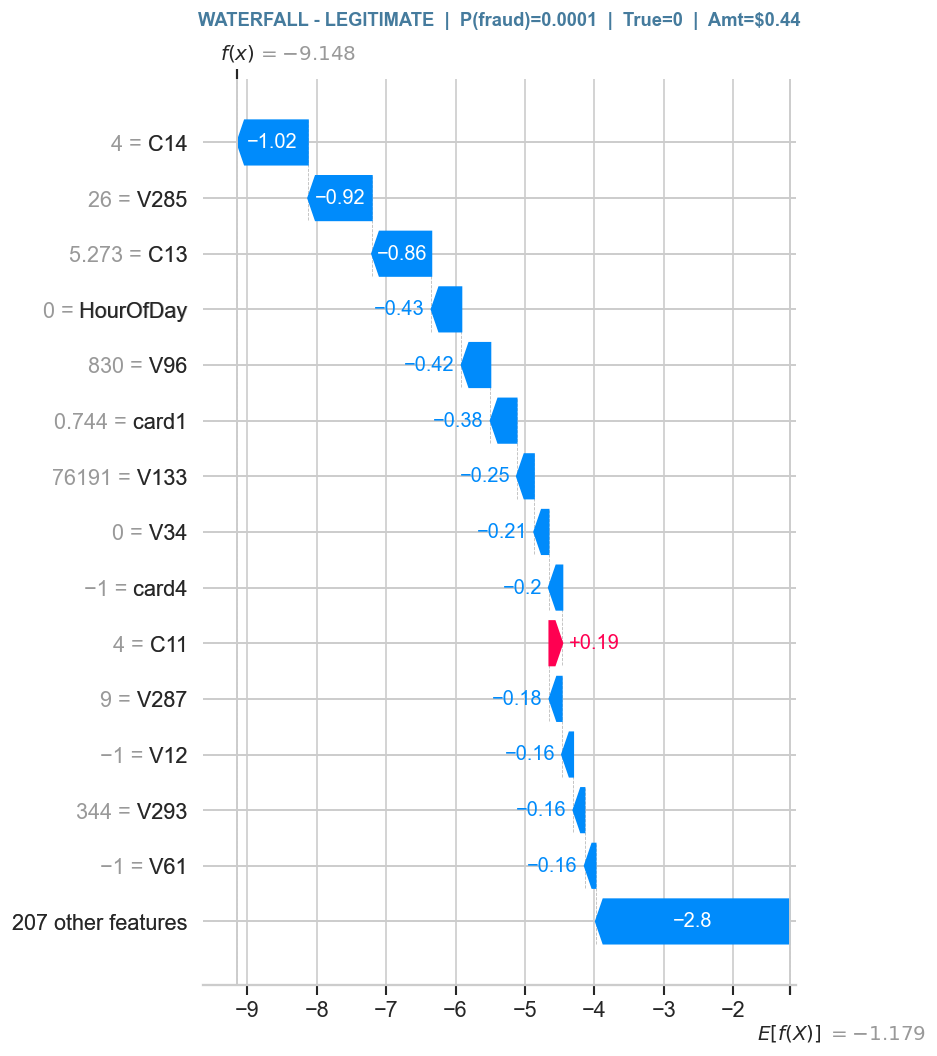

Saved shap_waterfall_legit.png


In [85]:
exp_legit = shap.Explanation(
    values        = sv[idx_legit],
    base_values   = base_val,
    data          = X_shap.iloc[idx_legit].values,
    feature_names = feature_names
)
 
plt.figure(figsize=(12, 7))
shap.waterfall_plot(exp_legit, max_display=15, show=False)
plt.title(
    f"WATERFALL - LEGITIMATE  |  "
    f"P(fraud)={proba_shap[idx_legit]:.4f}  |  "
    f"True={int(y_shap[idx_legit])}  |  "
    f"Amt=${X_shap.iloc[idx_legit]['TransactionAmt']:.2f}",
    fontsize=11, fontweight='bold', color=LEGIT_COLOR, pad=10
)
plt.tight_layout()
plt.savefig('shap_waterfall_legit.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved shap_waterfall_legit.png")

## Additional

### Step 1: Shap Dependence Plot

Primary feature    : HourOfDay   (highest mean |SHAP|)
Interaction colour : card6


<Figure size 1200x720 with 0 Axes>

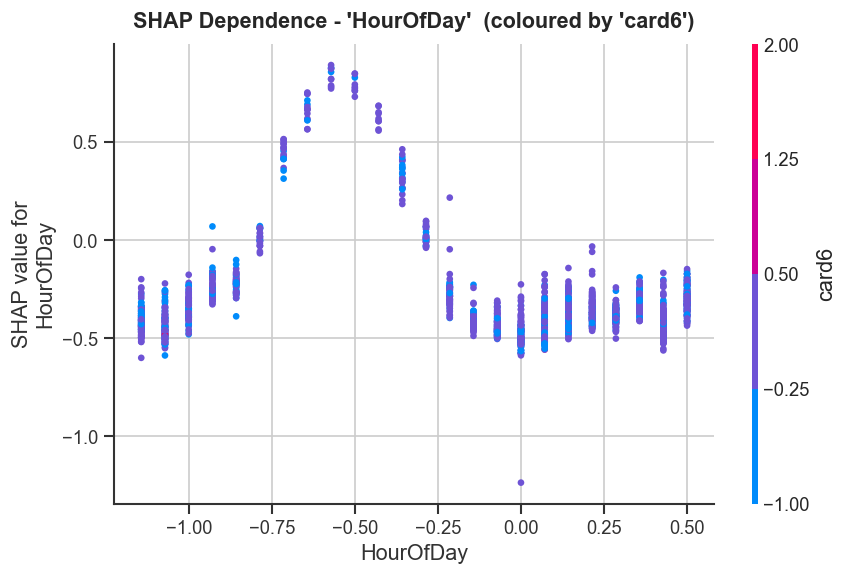

Saved shap_dependence.png


In [88]:
mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=feature_names)
top_feat      = mean_abs_shap.idxmax()
second_feat   = mean_abs_shap.nlargest(2).index[1]
 
print("Primary feature    :", top_feat, "  (highest mean |SHAP|)")
print("Interaction colour :", second_feat)
 
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    ind               = top_feat,
    shap_values       = sv,
    features          = X_shap,
    interaction_index = second_feat,
    show              = False
)
plt.title(f"SHAP Dependence - '{top_feat}'  (coloured by '{second_feat}')",
          fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved shap_dependence.png")

### Step 2: Explain all 3 transactions in plain English


In [90]:
def explain_in_english(idx, proba, true_label, shap_row, feature_names, case_name):
    pairs    = sorted(zip(feature_names, shap_row), key=lambda x: abs(x[1]), reverse=True)
    top5     = pairs[:5]
    positive = [(f, v) for f, v in top5 if v > 0]
    negative = [(f, v) for f, v in top5 if v < 0]
    amt      = X_shap.iloc[idx]['TransactionAmt']
 
    print(f"\n  {'='*54}")
    print(f"  {case_name}")
    print(f"  {'='*54}")
    print(f"  Amount      : ${amt:.2f}")
    print(f"  Model Score : {proba:.4f}   (True: {'FRAUD' if true_label == 1 else 'LEGIT'})")
 
    print("\n  WHY FRAUD IS SUSPECTED:")
    if positive:
        for feat, val in positive:
            strength = "STRONGLY" if abs(val) > 0.10 else "slightly"
            print(f"    [{val:+.4f}]  '{feat}' is {strength} increasing fraud risk")
    else:
        print("    (no positive SHAP drivers in top 5)")
 
    print("\n  WHY LEGITIMACY IS SUPPORTED:")
    if negative:
        for feat, val in negative:
            strength = "STRONGLY" if abs(val) > 0.10 else "slightly"
            print(f"    [{val:+.4f}]  '{feat}' is {strength} reducing fraud risk")
    else:
        print("    (no negative SHAP drivers in top 5)")
 
    print("\n  VERDICT:")
    if proba > 0.80:
        print(f"    HIGH-RISK ALERT  - {proba*100:.1f}% fraud confidence.")
        print(f"    Key trigger: '{positive[0][0] if positive else 'N/A'}'")
        print(f"    Action -> BLOCK transaction and contact card holder.")
    elif proba > 0.40:
        print(f"    AMBIGUOUS CASE   - Score={proba:.2f}. Signals conflict.")
        print(f"    Action -> ESCALATE to manual review team.")
    else:
        print(f"    LOW-RISK LEGIT   - Only {proba*100:.2f}% fraud probability.")
        print(f"    Key safety signal: '{negative[0][0] if negative else 'N/A'}'")
        print(f"    Action -> APPROVE and log normally.")

In [91]:
cases = [
    (idx_fraud,  proba_shap[idx_fraud],  y_shap[idx_fraud],  "CASE 1 - CONFIRMED FRAUD"),
    (idx_border, proba_shap[idx_border], y_shap[idx_border], "CASE 2 - BORDERLINE"),
    (idx_legit,  proba_shap[idx_legit],  y_shap[idx_legit],  "CASE 3 - LEGITIMATE"),
]
 
for idx, prob, true_lab, name in cases:
    explain_in_english(idx, prob, int(true_lab), sv[idx], feature_names, name)


  CASE 1 - CONFIRMED FRAUD
  Amount      : $-0.18
  Model Score : 0.9990   (True: FRAUD)

  WHY FRAUD IS SUSPECTED:
    [+2.0045]  'C1' is STRONGLY increasing fraud risk
    [+0.5326]  'C11' is STRONGLY increasing fraud risk
    [+0.5301]  'C12' is STRONGLY increasing fraud risk
    [+0.4859]  'V34' is STRONGLY increasing fraud risk
    [+0.4713]  'C8' is STRONGLY increasing fraud risk

  WHY LEGITIMACY IS SUPPORTED:
    (no negative SHAP drivers in top 5)

  VERDICT:
    HIGH-RISK ALERT  - 99.9% fraud confidence.
    Key trigger: 'C1'
    Action -> BLOCK transaction and contact card holder.

  CASE 2 - BORDERLINE
  Amount      : $0.07
  Model Score : 0.4995   (True: FRAUD)

  WHY FRAUD IS SUSPECTED:
    [+0.6122]  'C11' is STRONGLY increasing fraud risk
    [+0.4647]  'C8' is STRONGLY increasing fraud risk
    [+0.4074]  'C13' is STRONGLY increasing fraud risk

  WHY LEGITIMACY IS SUPPORTED:
    [-0.4598]  'C1' is STRONGLY reducing fraud risk
    [-0.4031]  'TransactionDT' is STRONGL

### Step 3: Compare SHAP importance vs model feature importance

In [93]:
# Compute SHAP importance

shap_imp = (pd.Series(np.abs(sv).mean(axis=0), index=feature_names)
              .sort_values(ascending=False).head(20).reset_index())
shap_imp.columns = ['feature', 'shap_importance']
shap_imp['shap_norm'] = (shap_imp['shap_importance'] /
                          shap_imp['shap_importance'].max() * 100).round(2)

In [94]:
# Compute LightGBM gain importance

lgb_imp = (pd.Series(model.booster_.feature_importance(importance_type='gain'),
                     index=feature_names)
             .sort_values(ascending=False).head(20).reset_index())
lgb_imp.columns = ['feature', 'lgb_importance']
lgb_imp['lgb_norm'] = (lgb_imp['lgb_importance'] /
                        lgb_imp['lgb_importance'].max() * 100).round(2)
 
print("\nTop 10 - SHAP Mean |Value| (normalised 0-100):")
print(shap_imp[['feature','shap_norm']].head(10).to_string(index=False))
 
print("\nTop 10 - LightGBM Gain Importance (normalised 0-100):")
print(lgb_imp[['feature','lgb_norm']].head(10).to_string(index=False))


Top 10 - SHAP Mean |Value| (normalised 0-100):
       feature  shap_norm
     HourOfDay     100.00
         card6      92.46
TransactionAmt      86.54
            C1      67.24
           C14      65.32
           C13      60.76
 TransactionDT      47.08
 P_emaildomain      43.31
         card2      42.21
           C11      38.81

Top 10 - LightGBM Gain Importance (normalised 0-100):
      feature  lgb_norm
        card6    100.00
    HourOfDay     41.24
          C14     41.07
          C11     32.10
           M6     19.27
        card4     18.20
           C1     17.72
          V34     16.97
P_emaildomain     16.76
           C8     15.81


## TASK 5 — Risk Segmentation & Fraud Pattern Analysis [ADVANCED]


### Step 1: Risk Tiers

In [97]:
# Cell 2 — Risk tier assignment
test_df = X_test.copy()
test_df['FraudProb'] = lgbm_probs
test_df['TrueLabel'] = y_test.values

def assign_tier(p):
    if p >= 0.75: return 'Critical'
    if p >= 0.40: return 'Suspicious'
    return 'Clear'

test_df['RiskTier'] = test_df['FraudProb'].apply(assign_tier)
tier_counts = test_df['RiskTier'].value_counts()
tier_order  = ['Critical', 'Suspicious', 'Clear']
print('=== Risk Tier Distribution ===')
print(tier_counts.to_string())
print(f'\nTotal: {len(test_df):,} transactions')

=== Risk Tier Distribution ===
RiskTier
Clear         113710
Suspicious      2212
Critical        2186

Total: 118,108 transactions


### Step 2: Tier Statistics

In [99]:
tier_stats = test_df.groupby('RiskTier').agg(
    Count      = ('FraudProb', 'count'),
    Avg_Amount = ('TransactionAmt', 'mean'),
    Avg_Hour   = ('HourOfDay', 'mean'),
    Fraud_Rate = ('TrueLabel', 'mean')
).round(3)
print('=== Tier Statistics ===')
print(tier_stats.loc[[t for t in tier_order if t in tier_stats.index]].to_string())

=== Tier Statistics ===
             Count  Avg_Amount  Avg_Hour  Fraud_Rate
RiskTier                                            
Critical      2186       0.760    -0.222       0.894
Suspicious    2212       1.300    -0.197       0.411
Clear       113710       0.797    -0.150       0.011


### Step 3 — Average TransactionAmt per Risk Tier

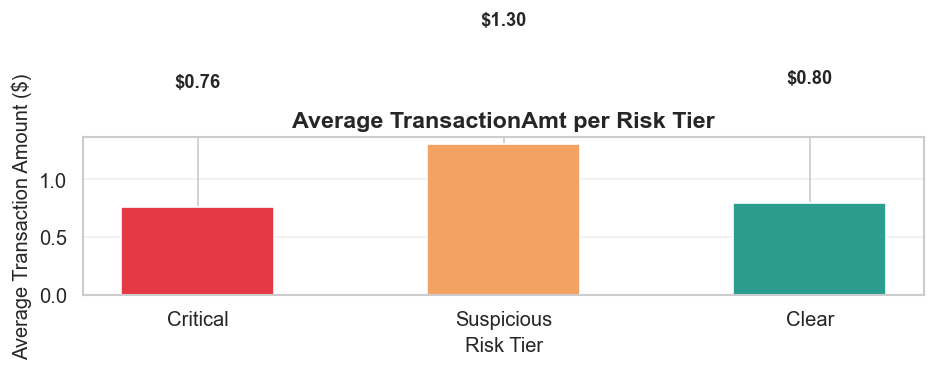

Saved: charts/avg_amt_per_tier.png
RiskTier
Critical      0.760280
Suspicious    1.300140
Clear         0.796742


In [101]:
import matplotlib.pyplot as plt

avg_amt = test_df.groupby('RiskTier')['TransactionAmt'].mean().reindex(tier_order)
colors  = ['#e63946', '#f4a261', '#2a9d8f']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(tier_order, avg_amt.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, avg_amt.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Risk Tier', fontsize=12)
ax.set_ylabel('Average Transaction Amount ($)', fontsize=12)
ax.set_title('Average TransactionAmt per Risk Tier', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/avg_amt_per_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/avg_amt_per_tier.png')
print(avg_amt.to_string())

### Step 4: Device Type Distribution Per Tier

In [103]:
if 'DeviceType' in test_df.columns:
    dist = test_df.groupby(['RiskTier','DeviceType']).size().unstack(fill_value=0)
    print(dist.loc[[t for t in tier_order if t in dist.index]].to_string())
else:
    print('DeviceType not in X_test — skipped.')

DeviceType not in X_test — skipped.


### Step 5 — Hour-of-Day Pattern per Risk Tier

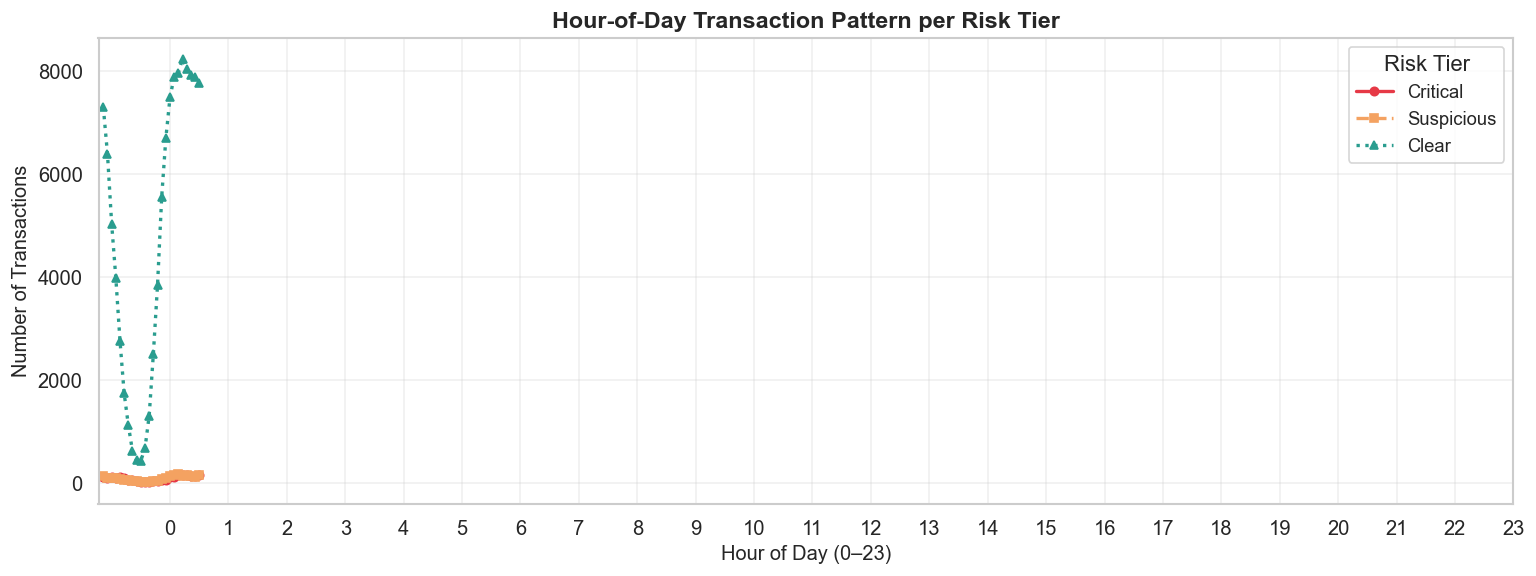

Saved: charts/hour_pattern_per_tier.png


In [105]:
hourly_tier = (
    test_df.groupby(['RiskTier', 'HourOfDay'])
    .size()
    .reset_index(name='TxnCount')
)

fig, ax = plt.subplots(figsize=(13, 5))
style   = {'Critical': ('#e63946', '-', 'o'),
            'Suspicious': ('#f4a261', '--', 's'),
            'Clear': ('#2a9d8f', ':', '^')}

for tier in tier_order:
    sub = hourly_tier[hourly_tier['RiskTier'] == tier]
    color, ls, marker = style[tier]
    ax.plot(sub['HourOfDay'], sub['TxnCount'],
            label=tier, color=color, linestyle=ls,
            marker=marker, markersize=5, lw=2)

ax.set_xlabel('Hour of Day (0–23)', fontsize=12)
ax.set_ylabel('Number of Transactions', fontsize=12)
ax.set_title('Hour-of-Day Transaction Pattern per Risk Tier', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend(title='Risk Tier', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/hour_pattern_per_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/hour_pattern_per_tier.png')

### Step 6 — Grouped Bar Chart (All Tiers)

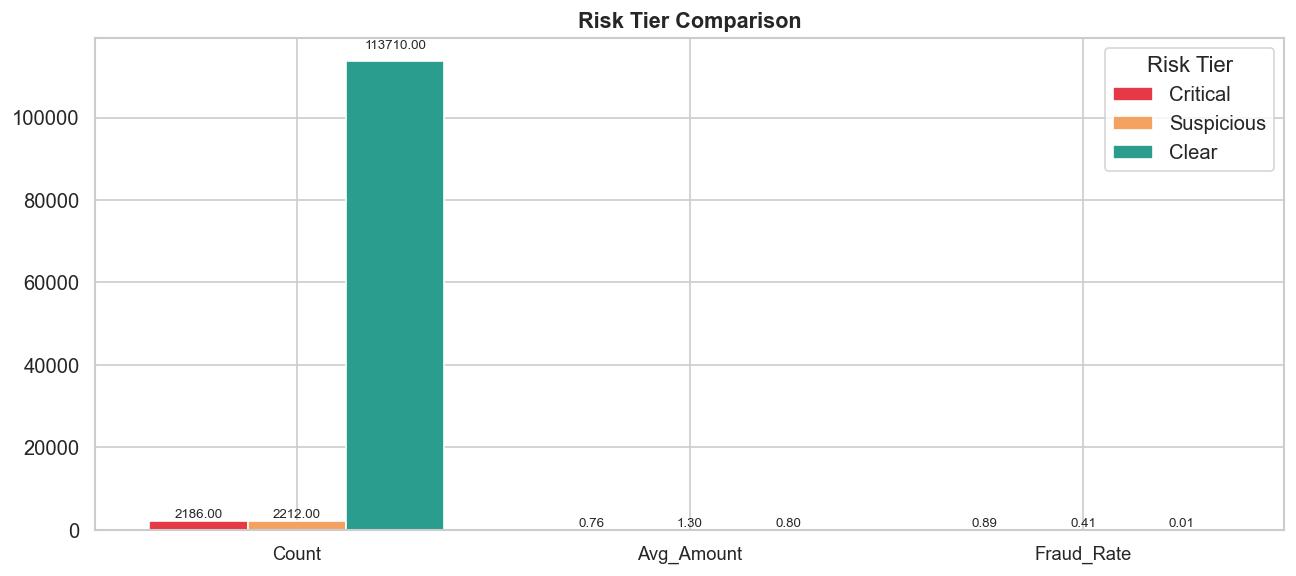

Saved: charts/risk_tier_grouped_bar.png


In [107]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Count', 'Avg_Amount', 'Fraud_Rate']
colors  = ['#e63946', '#f4a261', '#2a9d8f']
x, width = np.arange(len(metrics)), 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (tier, color) in enumerate(zip(tier_order, colors)):
    vals = [tier_stats.loc[tier, m] if tier in tier_stats.index else 0 for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=tier, color=color, edgecolor='white')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.02,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_title('Risk Tier Comparison', fontsize=13, fontweight='bold')
ax.legend(title='Risk Tier')
plt.tight_layout()
plt.savefig('charts/risk_tier_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/risk_tier_grouped_bar.png')

### Step 7 — Top 3 Fraud Patterns in Critical Tier

In [109]:
crit = test_df[test_df['RiskTier'] == 'Critical']
p75  = crit['TransactionAmt'].quantile(0.75)
night = crit[crit['HourOfDay'].between(0, 5)]

print('=== Top 3 Fraud Patterns — Critical Risk ===')
print(f'\nPattern 1 — High Transaction Amount')
print(f'  75th pct: ${p75:.2f}  |  {(crit["TransactionAmt"]>p75).mean()*100:.1f}% exceed it')
print(f'\nPattern 2 — Night-Hour (00:00-05:00)')
print(f'  {len(night):,} / {len(crit):,} critical txns at night ({len(night)/len(crit)*100:.1f}%)')
print(f'\nPattern 3 — High-Risk Device')
if 'DeviceRisk' in crit.columns:
    print(f'  {crit["DeviceRisk"].mean()*100:.1f}% flagged as high-risk device')
else:
    print('  DeviceRisk not available in X_test')

=== Top 3 Fraud Patterns — Critical Risk ===

Pattern 1 — High Transaction Amount
  75th pct: $0.99  |  22.3% exceed it

Pattern 2 — Night-Hour (00:00-05:00)
  1,133 / 2,186 critical txns at night (51.8%)

Pattern 3 — High-Risk Device
  DeviceRisk not available in X_test


## TASK 6 — Streamlit Fraud Operations Dashboard [ADVANCED]


#### Step 1 — Create Folders & Export Data

In [112]:
import os
import pickle

os.makedirs('dashboard', exist_ok=True)
os.makedirs('dashboard/charts', exist_ok=True)

# 1. Your existing data export code
export_df = X_test.copy()
export_df['TransactionID'] = df.loc[X_test.index, 'TransactionID'].values
export_df['FraudProb']     = lgbm_probs
export_df['TrueLabel']     = y_test.values
export_df['RiskTier']      = export_df['FraudProb'].apply(assign_tier)
export_df.to_csv('dashboard/test_results.csv', index=False)
print(f'Exported {len(export_df)} rows to dashboard/test_results.csv')

# 2. APPEND THIS EXACT LINE HERE to save the model artifact as well
with open('dashboard/model.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)

print('Successfully saved dashboard/model.pkl')

Exported 118108 rows to dashboard/test_results.csv
Successfully saved dashboard/model.pkl


### PAGE 1 — OVERVIEW

### Step 1 — Total Transactiom

In [115]:
total_txn = len(export_df)
print(f'Total Transactions : {total_txn:,}')

Total Transactions : 118,108


### Step 2 - Total Fraud Count

In [117]:
total_fraud = export_df['TrueLabel'].sum()
print(f'Total Fraud Count  : {total_fraud:,}')

Total Fraud Count  : 4,133


### Step 3 - Detection Rate

In [119]:
# Detection rate = fraud caught by model / total actual fraud
fraud_caught    = ((export_df['FraudProb'] >= best_thresh) & (export_df['TrueLabel'] == 1)).sum()
detection_rate  = fraud_caught / total_fraud * 100
print(f'Fraud Caught       : {fraud_caught:,}')
print(f'Detection Rate     : {detection_rate:.2f}%')

Fraud Caught       : 2,675
Detection Rate     : 64.72%


### Step 4 — Average Fraud Amount

In [121]:
avg_fraud_amt = export_df[export_df['TrueLabel'] == 1]['TransactionAmt'].mean()
print(f'Average Fraud Amount : ${avg_fraud_amt:.2f}')

Average Fraud Amount : $1.05


### Step 6 - Overview KPI Summary Table

In [123]:
kpi = pd.DataFrame({
    'Metric': ['Total Transactions', 'Total Fraud Count',
               'Detection Rate (%)', 'Avg Fraud Amount ($)'],
    'Value' : [f'{total_txn:,}', f'{total_fraud:,}',
               f'{detection_rate:.2f}%', f'${avg_fraud_amt:.2f}']
})
print('=== Page 1 — Overview KPIs ===')
print(kpi.to_string(index=False))

=== Page 1 — Overview KPIs ===
              Metric   Value
  Total Transactions 118,108
   Total Fraud Count   4,133
  Detection Rate (%)  64.72%
Avg Fraud Amount ($)   $1.05


## Page 2 — Transaction Explorer

### Step 7 — Searchable Table by TransactionID

In [126]:
def search_by_id(transaction_id):
    result = export_df[export_df['TransactionID'] == int(transaction_id)]
    if result.empty:
        print(f'TransactionID {transaction_id} not found.')
    else:
        cols = ['TransactionID','TransactionAmt','HourOfDay','RiskTier','FraudProb','TrueLabel']
        print(result[cols].to_string(index=False))
    return result

# Example search
sample_id = export_df['TransactionID'].iloc[0]
print(f'--- Searching for TransactionID: {sample_id} ---')
search_by_id(sample_id)

--- Searching for TransactionID: 2987000 ---
 TransactionID  TransactionAmt  HourOfDay RiskTier  FraudProb  TrueLabel
       2987000          0.4769  -1.142857    Clear   0.011412          0


,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,V319,V320,V321,AmtToMeanRatio,HourOfDay,LogTransactionAmt,TransactionID,FraudProb,TrueLabel,RiskTier
0,0.067539,0.4769,0.0,-0.257087,0.644295,0.0,0.0,0.0,-1.0,-0.277778,...,0.0,0.0,0.0,0.4769,-1.142857,0.422976,2987000,0.011412,0,Clear


### Step 8 — Filterable Transactions (by Tier, Hour, Amount)

In [128]:
def filter_transactions(tier='All', hour_min=0, hour_max=23, amt_min=0, amt_max=None):
    if amt_max is None:
        amt_max = export_df['TransactionAmt'].max()
    mask = (
        export_df['HourOfDay'].between(hour_min, hour_max) &
        export_df['TransactionAmt'].between(amt_min, amt_max)
    )
    if tier != 'All':
        mask &= export_df['RiskTier'] == tier
    result = export_df[mask][['TransactionID','TransactionAmt',
                               'HourOfDay','RiskTier','FraudProb','TrueLabel']]
    print(f'Filter → Tier={tier} | Hour={hour_min}-{hour_max} | Amt=${amt_min}-${amt_max:.0f}')
    print(f'Matching rows : {len(result):,}')
    print(result.head(10).to_string(index=False))
    return result

# Example: Critical tier, night hours, high amount
filtered = filter_transactions(tier='Critical', hour_min=0, hour_max=5, amt_min=100)

Filter → Tier=Critical | Hour=0-5 | Amt=$100-$73
Matching rows : 0
Empty DataFrame
Columns: [TransactionID, TransactionAmt, HourOfDay, RiskTier, FraudProb, TrueLabel]
Index: []


### Step 9 — Live Risk Score by TransactionID

In [130]:
def live_risk_score(transaction_id):
    row = export_df[export_df['TransactionID'] == int(transaction_id)]
    if row.empty:
        print(f'TransactionID {transaction_id} not found.')
        return
    prob = row['FraudProb'].values[0]
    tier = row['RiskTier'].values[0]
    amt  = row['TransactionAmt'].values[0]
    true = row['TrueLabel'].values[0]
    icon = {'Critical':'🔴','Suspicious':'🟡','Clear':'🟢'}.get(tier, '⚪')
    print(f'TransactionID   : {transaction_id}')
    print(f'Amount          : ${amt:.2f}')
    print(f'Fraud Prob      : {prob:.4f}')
    print(f'Risk Tier       : {icon} {tier}')
    print(f'Actual Label    : {"FRAUD" if true==1 else "LEGIT"}')

# Test on a fraud case
fraud_id = export_df[export_df['TrueLabel']==1]['TransactionID'].iloc[0]
print('--- High-risk example ---')
live_risk_score(fraud_id)

# Test on a legit case
legit_id = export_df[export_df['TrueLabel']==0]['TransactionID'].iloc[0]
print('\n--- Low-risk example ---')
live_risk_score(legit_id)

--- High-risk example ---
TransactionID   : 2987058
Amount          : $-0.70
Fraud Prob      : 0.9228
Risk Tier       : 🔴 Critical
Actual Label    : FRAUD

--- Low-risk example ---
TransactionID   : 2987000
Amount          : $0.48
Fraud Prob      : 0.0114
Risk Tier       : 🟢 Clear
Actual Label    : LEGIT


## Page 3 — SHAP Explainer

### Step 10 — SHAP Waterfall for any TransactionID

In [133]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Added 'model' as a parameter to the function
def shap_explain(transaction_id, model):
    row = export_df[export_df['TransactionID'] == int(transaction_id)]
    if row.empty:
        print(f'TransactionID {transaction_id} not found.')
        return
        
    skip = ['TransactionID', 'FraudProb', 'TrueLabel', 'RiskTier']
    feat_cols = [c for c in export_df.columns if c not in skip]
    X_row = row[feat_cols].values
    
    # 2. Use the passed model here
    explainer = shap.TreeExplainer(model)
    sv_row = explainer.shap_values(X_row)
    
    # Handle binary classification lists if necessary
    if isinstance(sv_row, list): 
        sv_row = sv_row[1]
    # Handle 3D arrays that sometimes come from certain SHAP versions
    if len(sv_row.shape) == 3:
        sv_row = sv_row[:, :, 1] if sv_row.shape[2] == 2 else sv_row[:, :, 0]

    # Handle expected_value formatting differences
    base_val = explainer.expected_value
    if isinstance(base_val, (list, np.ndarray)) and len(base_val) > 1:
        base_val = base_val[1]

    exp = shap.Explanation(
        values        = sv_row[0],
        base_values   = base_val,
        data          = X_row[0],
        feature_names = feat_cols
    )
    
    plt.figure(figsize=(11, 6))
    shap.waterfall_plot(exp, max_display=15, show=False)
    
    prob = row['FraudProb'].values[0]
    tier = row['RiskTier'].values[0]
    
    plt.title(f'SHAP Waterfall — TxnID {transaction_id}  |  P(fraud)={prob:.4f}  |  {tier}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'charts/shap_txn_{transaction_id}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: charts/shap_txn_{transaction_id}.png')

### Step 11 — Plain-English Explanation for any TransactionID

In [135]:
sample_fraud_row = export_df[export_df['TrueLabel'] == 1]

if sample_fraud_row.empty:
    # If no fraud cases are in the test subset, just grab the very first available row
    valid_id = export_df['TransactionID'].iloc[0]
    print(f"No fraud rows found in export_df. Using a generic Transaction ID instead.")
else:
    valid_id = sample_fraud_row['TransactionID'].iloc[0]

print(f"Running explanation for verified Transaction ID: {valid_id}\n")

# 2. Call your plain English explanation function using your model variable (lgbm_model)
plain_english_explanation(valid_id, lgbm_model)

print("\n" + "="*55 + "\n")

# 3. Call your SHAP waterfall plot function
shap_explain(valid_id, lgbm_model)

Running explanation for verified Transaction ID: 2987058



NameError: name 'plain_english_explanation' is not defined

### Step 12 — Write Full dashboard/app.py

In [ ]:
app_code = '''
import pickle, os, shap
import plotly.express as px
import matplotlib.pyplot as plt

st.set_page_config(page_title="FraudOps", layout="wide")

@st.cache_data
def load_data():
    return pd.read_csv("dashboard/test_results.csv")

@st.cache_resource
def load_model():
    with open("dashboard/model.pkl", "rb") as f:
        return pickle.load(f)

df    = load_data()
model = load_model()

# Sidebar
with st.sidebar:
    st.title("FraudOps")
    page       = st.radio("Navigate", ["Overview", "Transaction Explorer", "SHAP Explainer"])
    st.markdown("---")
    tier_sel   = st.selectbox("Risk Tier", ["All", "Critical", "Suspicious", "Clear"])
    hour_range = st.slider("Hour of Day", 0, 23, (0, 23))
    amt_max    = int(df["TransactionAmt"].max())
    amt_range  = st.slider("Transaction Amount ($)", 0, amt_max, (0, amt_max))

mask = (
    df["HourOfDay"].between(*hour_range) &
    df["TransactionAmt"].between(*amt_range)
)
if tier_sel != "All":
    mask &= df["RiskTier"] == tier_sel
filtered = df[mask]

# PAGE 1 — Overview
if page == "Overview":
    st.title("Fraud Operations Overview")
    total_txn      = len(filtered)
    total_fraud    = filtered["TrueLabel"].sum()
    detection_rate = filtered["TrueLabel"].mean() * 100
    avg_fraud_amt  = filtered[filtered["TrueLabel"]==1]["TransactionAmt"].mean()
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Total Transactions",  f"{total_txn:,}")
    c2.metric("Total Fraud Count",   f"{int(total_fraud):,}")
    c3.metric("Detection Rate",      f"{detection_rate:.2f}%")
    c4.metric("Avg Fraud Amount",    f"${avg_fraud_amt:.2f}")
    fig1 = px.histogram(filtered, x="HourOfDay", color="RiskTier", nbins=24,
                         title="Transaction Count by Hour of Day",
                         color_discrete_map={"Critical":"#e63946","Suspicious":"#f4a261","Clear":"#2a9d8f"})
    st.plotly_chart(fig1, use_container_width=True)
    tc   = filtered["RiskTier"].value_counts().reset_index()
    fig2 = px.pie(tc, names="RiskTier", values="count", hole=0.4,
                   title="Risk Tier Breakdown",
                   color="RiskTier",
                   color_discrete_map={"Critical":"#e63946","Suspicious":"#f4a261","Clear":"#2a9d8f"})
    st.plotly_chart(fig2, use_container_width=True)

# PAGE 2 — Transaction Explorer
elif page == "Transaction Explorer":
    st.title("Transaction Explorer")
    search = st.text_input("Search by TransactionID")
    if search:
        view = df[df["TransactionID"].astype(str).str.contains(search)]
    else:
        view = filtered
    st.dataframe(
        view[["TransactionID","TransactionAmt","HourOfDay",
              "RiskTier","FraudProb","TrueLabel"]].head(500),
        use_container_width=True
    )
    if search:
        row = df[df["TransactionID"].astype(str) == search]
        if not row.empty:
            st.markdown("#### Live Risk Score")
            prob = row["FraudProb"].values[0]
            tier = row["RiskTier"].values[0]
            icon = {"Critical":"🔴","Suspicious":"🟡","Clear":"🟢"}.get(tier,"")
            r1, r2, r3 = st.columns(3)
            r1.metric("Fraud Probability", f"{prob:.4f}")
            r2.metric("Risk Tier", f"{icon} {tier}")
            r3.metric("Amount", f"${row['TransactionAmt'].values[0]:.2f}")

# PAGE 3 — SHAP Explainer
elif page == "SHAP Explainer":
    st.title("SHAP Explainer")
    tid = st.text_input("Enter TransactionID")
    if tid:
        row = df[df["TransactionID"].astype(str) == tid]
        if row.empty:
            st.warning("TransactionID not found.")
        else:
            prob = row["FraudProb"].values[0]
            tier = row["RiskTier"].values[0]
            st.metric("Fraud Probability", f"{prob:.4f}")
            st.metric("Risk Tier", tier)
            skip      = ["TransactionID","FraudProb","TrueLabel","RiskTier"]
            feat_cols = [c for c in df.columns if c not in skip]
            X_row     = row[feat_cols].values
            explainer = shap.TreeExplainer(model)
            sv_row    = explainer.shap_values(X_row)
            if isinstance(sv_row, list): sv_row = sv_row[1]
            fig, ax = plt.subplots(figsize=(10, 5))
            shap.waterfall_plot(
                shap.Explanation(values=sv_row[0],
                                 base_values=explainer.expected_value,
                                 data=X_row[0], feature_names=feat_cols),
                max_display=15, show=False)
            st.pyplot(fig)
            st.markdown("**Plain-English Explanation:**")
            top3 = np.argsort(np.abs(sv_row[0]))[::-1][:3]
            for i in top3:
                d = "increased" if sv_row[0][i] > 0 else "decreased"
                st.write(f"- `{feat_cols[i]}` {d} fraud risk by {abs(sv_row[0][i]):.4f} SHAP units.")
'''
# Change 'w' to include encoding='utf-8'
with open('dashboard/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
    
print('dashboard/app.py written successfully with UTF-8 encoding.')

## Additional requirements 

In [ ]:
import os

# Create directory structure
os.makedirs('dashboard', exist_ok=True)

app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import pickle, os, shap
import plotly.express as px
import matplotlib.pyplot as plt

st.set_page_config(page_title="FraudOps", layout="wide")

@st.cache_data
def load_data():
    return pd.read_csv("dashboard/test_results.csv")

@st.cache_resource
def load_model():
    with open("dashboard/model.pkl", "rb") as f:
        return pickle.load(f)

df    = load_data()
model = load_model()

# Sidebar Setup
with st.sidebar:
    st.title("FraudOps")
    page       = st.radio("Navigate", ["Overview", "Transaction Explorer", "SHAP Explainer"])
    st.markdown("---")
    tier_sel   = st.selectbox("Risk Tier", ["All", "Critical", "Suspicious", "Clear"])
    hour_range = st.slider("Hour of Day", 0, 23, (0, 23))
    amt_max    = int(df["TransactionAmt"].max())
    amt_range  = st.slider("Transaction Amount ($)", 0, amt_max, (0, amt_max))

mask = (
    df["HourOfDay"].between(*hour_range) &
    df["TransactionAmt"].between(*amt_range)
)
if tier_sel != "All":
    mask &= df["RiskTier"] == tier_sel
filtered = df[mask]

# PAGE 1 — Overview
if page == "Overview":
    st.title("Fraud Operations Overview")
    total_txn      = len(filtered)
    total_fraud    = filtered["TrueLabel"].sum()
    detection_rate = filtered["TrueLabel"].mean() * 100 if total_txn > 0 else 0
    avg_fraud_amt  = filtered[filtered["TrueLabel"]==1]["TransactionAmt"].mean() if total_fraud > 0 else 0
    
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Total Transactions",  f"{total_txn:,}")
    c2.metric("Total Fraud Count",   f"{int(total_fraud):,}")
    c3.metric("Detection Rate",      f"{detection_rate:.2f}%")
    c4.metric("Avg Fraud Amount",    f"${avg_fraud_amt:.2f}")
    
    fig1 = px.histogram(filtered, x="HourOfDay", color="RiskTier", nbins=24,
                         title="Transaction Count by Hour of Day",
                         color_discrete_map={"Critical":"#e63946","Suspicious":"#f4a261","Clear":"#2a9d8f"})
    st.plotly_chart(fig1, use_container_width=True)
    
    tc   = filtered["RiskTier"].value_counts().reset_index()
    fig2 = px.pie(tc, names="RiskTier", values="count", hole=0.4,
                   title="Risk Tier Breakdown",
                   color="RiskTier",
                   color_discrete_map={"Critical":"#e63946","Suspicious":"#f4a261","Clear":"#2a9d8f"})
    st.plotly_chart(fig2, use_container_width=True)

# PAGE 2 — Transaction Explorer
elif page == "Transaction Explorer":
    st.title("Transaction Explorer")
    search = st.text_input("Search by TransactionID")
    if search:
        view = df[df["TransactionID"].astype(str).str.contains(search)]
    else:
        view = filtered
    st.dataframe(
        view[["TransactionID","TransactionAmt","HourOfDay",
              "RiskTier","FraudProb","TrueLabel"]].head(500),
        use_container_width=True
    )
    if search:
        row = df[df["TransactionID"].astype(str) == search]
        if not row.empty:
            st.markdown("#### Live Risk Score")
            prob = row["FraudProb"].values[0]
            tier = row["RiskTier"].values[0]
            icon = {"Critical":"🔴","Suspicious":"🟡","Clear":"🟢"}.get(tier,"")
            r1, r2, r3 = st.columns(3)
            r1.metric("Fraud Probability", f"{prob:.4f}")
            r2.metric("Risk Tier", f"{icon} {tier}")
            r3.metric("Amount", f"${row['TransactionAmt'].values[0]:.2f}")

# PAGE 3 — SHAP Explainer
elif page == "SHAP Explainer":
    st.title("SHAP Explainer")
    tid = st.text_input("Enter TransactionID")
    if tid:
        row = df[df["TransactionID"].astype(str) == tid]
        if row.empty:
            st.warning("TransactionID not found.")
        else:
            prob = row["FraudProb"].values[0]
            tier = row["RiskTier"].values[0]
            st.metric("Fraud Probability", f"{prob:.4f}")
            st.metric("Risk Tier", tier)
            skip      = ["TransactionID","FraudProb","TrueLabel","RiskTier"]
            feat_cols = [c for c in df.columns if c not in skip]
            X_row     = row[feat_cols].values
            explainer = shap.TreeExplainer(model)
            sv_row    = explainer.shap_values(X_row)
            if isinstance(sv_row, list): sv_row = sv_row[1]
            
            fig, ax = plt.subplots(figsize=(10, 5))
            shap.waterfall_plot(
                shap.Explanation(values=sv_row[0],
                                 base_values=explainer.expected_value,
                                 data=X_row[0], feature_names=feat_cols),
                max_display=15, show=False)
            st.pyplot(fig)
            
            st.markdown("**Plain-English Explanation:**")
            top3 = np.argsort(np.abs(sv_row[0]))[::-1][:3]
            for i in top3:
                d = "increased" if sv_row[0][i] > 0 else "decreased"
                st.write(f"- `{feat_cols[i]}` {d} fraud risk by {abs(sv_row[0][i]):.4f} SHAP units.")
"""

# Force UTF-8 encoding to avoid Windows OS crashes with Emojis
with open('dashboard/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print('dashboard/app.py successfully written.')